# Applying supervised learning to predict student dropout using Neural Networks

# Beginning of the notebook

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.optimizers import Adam, RMSprop
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
from keras.layers import Dense, Dropout, InputLayer
from keras import regularizers
import gc
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, auc,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve, ConfusionMatrixDisplay)

from tqdm import tqdm 
from itertools import product
import os
import random
import textwrap

import math
from scipy.stats import pearsonr, spearmanr, shapiro, levene, mannwhitneyu
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from datetime import date
from sklearn.pipeline import Pipeline
import xgboost as xgb
import shap
from xgboost import plot_importance
from sklearn.model_selection import GridSearchCV

# Stage 3 data

In [2]:
#| echo: false
# Load data
df3 = pd.read_csv('assets/student_dropout/figures/student_dropout_data_stage_3.csv')

In [3]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-null  object 
 14  Assess

In [4]:
# Remove unnecessary columns
df3.drop('LearnerCode', axis=1, inplace=True)

### Remove columns with high cardinality (use >200 unique values, as a guideline for this data set).

High cardinality refers to columns that contain a large number of unique values. In this case the recommendation is to remove columns with >200 unique values. This may need adjustment based on specific dataset and analysis goals.
This is important because columns with high cardinality can lead to overfitting of machine learning models, creates sparse data when one-hot encoded significantly increasing memory usage.

In [5]:
# Get list of columns to remove
high_cardinality_cols_s3 = [col for col in df3.columns if df3[col].nunique() > 200]
print("High cardinality columns:", high_cardinality_cols_s3)

High cardinality columns: ['DateofBirth', 'HomeState', 'HomeCity', 'ProgressionDegree', 'UnauthorisedAbsenceCount']


HomeState and HomeCity are unlikely to provide any useful information regarding the student’s likelihood to drop out. So they will be remove from the dataset considering their high cardinality.

DateOfBirth will also be removed due to its high cardinality. However, first I will create a new column called Age which will be the difference between the current date and the date of birth. This will be a more useful feature for the analysis.

ProgressionDegree will also be removed due to its high cardinality. This column contains 2616 unique values which is too high for encoding. Nonetheless, it is important to note that this column contains information about the degree the student is studying. This information may be useful for the analysis, but it is not possible to encode it in a meaningful way. 

UnauthorisedAbsenceCount will not be removed, but engineered instead. 

In [6]:
# Remove these columns
df3_reduced = df3.drop(columns=['HomeState', 'HomeCity'], axis=1)

In [7]:
# Convert DateofBirth to Age

df3_reduced['DateofBirth'] = pd.to_datetime(df3_reduced['DateofBirth'], dayfirst=True, errors='coerce')

df3_reduced['Age'] = (date.today().year - df3_reduced['DateofBirth'].dt.year)

# Drop the original DateofBirth column
df3_reduced.drop('DateofBirth', axis=1, inplace=True)

In [8]:
# Drop the ProgressionDegree column
df3_reduced.drop('ProgressionDegree', axis=1, inplace=True)

#### Based on analysis performed for Stage 2 data, UnauthorisedAbsenceCount and AuthorisedAbsenceCount were transformed into categories by binning. 

In [9]:
# Define bins (adjust thresholds based on domain knowledge)
bins = [0, 10, 50, 100, float('inf')]
labels = ['<10', '11-50', '51-100', '>100']

# Create a new binned column
df3_reduced['Unauthorised_AbsenceCategory'] = pd.cut(
    df3_reduced['UnauthorisedAbsenceCount'],
    bins=bins,
    labels=labels,
    right=False
)

In [10]:
display(df3_reduced.head(2))

,CentreName,BookingType,LeadSource,DiscountType,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age,Unauthorised_AbsenceCategory
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,NaN,NaN,27,NaN
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,93.0,5.0,27,<10


#### Now we can drop UnauthorisedAbsenceCount

In [11]:
# Drop the ProgressionDegree column
df3_reduced.drop('UnauthorisedAbsenceCount', axis=1, inplace=True)

#### Repeat the binning process for the AuthorisedAbsenceCount to keep it consistent

In [12]:
# Define bins (adjust thresholds based on domain knowledge)
bins = [0, 10, 50, 100, float('inf')]
labels = ['<10', '11-50', '51-100', '>100']

# Create a new binned column
df3_reduced['Autorised_AbsenceCategory'] = pd.cut(
    df3_reduced['AuthorisedAbsenceCount'],
    bins=bins,
    labels=labels,
    right=False
)

In [13]:
# Drop the ProgressionDegree column
df3_reduced.drop('AuthorisedAbsenceCount', axis=1, inplace=True)

### Remove columns with > 50% data missing.

In [14]:
# Get list of columns to remove
high_nas_cols_s3 = [col for col in df3_reduced.columns if df3_reduced[col].isna().sum() > 0.5 * len(df3_reduced)]
print("High NA columns:", high_nas_cols_s3)

High NA columns: ['DiscountType']


In [15]:
# Drop the DiscountType column
df3_reduced.drop('DiscountType', axis=1, inplace=True)

In [16]:
display(df3_reduced.head(2))

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,Age,Unauthorised_AbsenceCategory,Autorised_AbsenceCategory
0,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,27,NaN,NaN
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,27,<10,51-100


#### Check new Features

In [17]:
# Check number of unique values in new features
print("Unique values in AssessedModules:", df3_reduced['AssessedModules'].nunique())
print("Count of each unique value in AssessedModules:")
print(df3_reduced['AssessedModules'].value_counts())

print("Unique values in PassedModules:", df3_reduced['PassedModules'].nunique())
print("Count of each unique value in PassedModules:")
print(df3_reduced['PassedModules'].value_counts())

print("Unique values in FailedModules:", df3_reduced['FailedModules'].nunique())
print("Count of each unique value in FailedModules:")
print(df3_reduced['FailedModules'].value_counts())

Unique values in AssessedModules: 12
Count of each unique value in AssessedModules:
AssessedModules
6.0     6426
4.0     4749
7.0     3858
8.0     3805
5.0     1384
9.0      958
3.0      521
10.0     439
1.0      308
2.0      217
11.0     161
12.0       2
Name: count, dtype: int64
Unique values in PassedModules: 12
Count of each unique value in PassedModules:
PassedModules
6.0     5858
4.0     4301
7.0     3673
8.0     3555
0.0     1536
5.0     1099
9.0      816
3.0      650
1.0      441
2.0      426
10.0     342
11.0     131
Name: count, dtype: int64
Unique values in FailedModules: 11
Count of each unique value in FailedModules:
FailedModules
0.0     18598
1.0      1514
3.0       710
2.0       658
4.0       589
5.0       469
6.0       184
7.0        58
8.0        28
9.0        11
10.0        9
Name: count, dtype: int64


#### Examine features with NAs more in detail.

In [18]:
# Create DataFrame with only rows containing NA values
na_rows_df = df3_reduced[df3_reduced.isna().any(axis=1)]

# Show summary of NA rows
print(f"Found {len(na_rows_df)} rows with missing values")
display(na_rows_df.head())

# Optional: Show which columns have NAs in these rows
print("\nColumns with NAs in these rows:")
print(na_rows_df.isna().sum()[na_rows_df.isna().sum() > 0])

Found 2310 rows with missing values


,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,Age,Unauthorised_AbsenceCategory,Autorised_AbsenceCategory
0,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,27,NaN,NaN
4,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,29,NaN,NaN
6,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Business; Economics; Accounting and Real Estat...,False,No,NaN,NaN,NaN,University of Aberdeen,23,11-50,11-50
17,ISC_Aberdeen,Direct,Sponsor,Male,Iraqi,Pre-Masters,Science and Engineering Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,27,NaN,NaN
36,ISC_Aberdeen,Direct,Digital (Web),Male,Indian,Pre-Masters,Science and Engineering Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,30,NaN,NaN



Columns with NAs in these rows:
AssessedModules                 2231
PassedModules                   2231
FailedModules                   2231
Unauthorised_AbsenceCategory     208
Autorised_AbsenceCategory        208
dtype: int64


#### Remove NAs from Unauthorised_AbsenceCategory, Autorised_AbsenceCategory only, because the fraction in these features is very small. Therefore their removal is unlikely to affect negatively the performance of the models.

In [19]:
# Check shape of original dataframe
print("Original shape:", df3_reduced.shape)

# Drop rows with NAs ONLY in the specified absence categories
cols_to_check = ['Unauthorised_AbsenceCategory', 'Autorised_AbsenceCategory']
df3_encoded_clean = df3_reduced.dropna(subset=cols_to_check)

# Check shape of cleaned dataframe
print("Cleaned shape:", df3_encoded_clean.shape)

# Show how many rows were dropped
rows_dropped = df3_reduced.shape[0] - df3_encoded_clean.shape[0]
print(f"Rows dropped (missing in absence categories): {rows_dropped}")

# Optional: Verify NAs still exist in other columns
print("\nRemaining NAs in other columns:")
print(df3_encoded_clean.isna().sum()[df3_encoded_clean.isna().sum() > 0])

Original shape: (25059, 16)
Cleaned shape: (24851, 16)
Rows dropped (missing in absence categories): 208

Remaining NAs in other columns:
AssessedModules    2102
PassedModules      2102
FailedModules      2102
dtype: int64


In [20]:
display(df3_encoded_clean.head(2))

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,Age,Unauthorised_AbsenceCategory,Autorised_AbsenceCategory
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,27,<10,51-100
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,University of Aberdeen,25,<10,51-100


### Visualize the distribution of the new features

In [21]:
# Create a new df with only the new features for visualization purposes.
df3_view = df3_encoded_clean[['AssessedModules', 'PassedModules', 'FailedModules']]

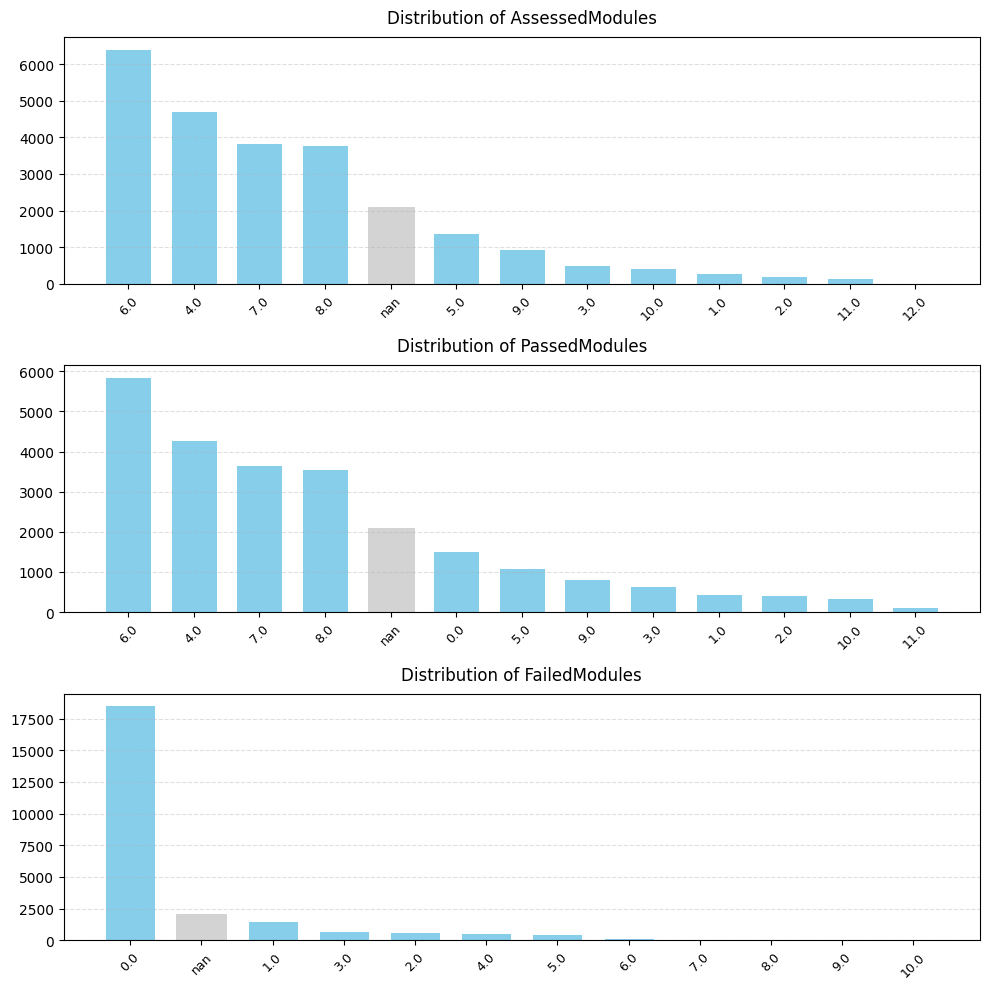

In [22]:
# @title: Data Distribution
def make_barplots(data, n_cols=1, n_rows=3, figsize=(10, 10), color='skyblue', 
                 na_color='lightgray', title_fontsize=12, label_fontsize=10, 
                 tick_label_fontsize=9, rotation=45, max_unique_cat=20, 
                 bar_width=0.7, grid=True, **kwargs):
    """
    Generate bar plots for categorical features in a DataFrame.
    
    Parameters:
        data: DataFrame or array-like
        n_cols: Number of columns in subplot grid
        ... [other params]
    """
    # Convert to DataFrame if numpy array
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data)
    
    # Select only categorical columns
    cat_cols = [col for col in data.columns 
               if data[col].dtype == 'object' or 
               data[col].nunique() <= max_unique_cat]
    
    # Calculate required rows if not specified
    if n_rows == 'auto':
        n_rows = int(np.ceil(len(cat_cols) / n_cols))
    
    # Create figure and axes grid
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i, (ax, column) in enumerate(zip(axes, cat_cols)):
        if i >= len(cat_cols):
            ax.axis('off')
            continue
            
        # Get value counts (including NA)
        value_counts = data[column].value_counts(dropna=False)
        
        # Plot bars
        x_pos = np.arange(len(value_counts))
        bars = ax.bar(x_pos, value_counts.values, 
                     width=bar_width, color=color, 
                     edgecolor='white', linewidth=0.7)
        
        # Customize plot
        ax.set_title(f'Distribution of {column}', fontsize=title_fontsize, pad=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(value_counts.index.astype(str), 
                         rotation=rotation,
                         fontsize=tick_label_fontsize)
        if grid:
            ax.grid(axis='y', linestyle='--', alpha=0.4)
        
        # Color NA bars differently
        if value_counts.index.isna().any():
            na_idx = np.where(value_counts.index.isna())[0]
            bars[na_idx[0]].set_color(na_color)
    
    plt.tight_layout()
    plt.show()
make_barplots(df3_view)

### Create feature RateModuleSuccess:  (PassedModules - FailedModules/ AssessedModules). This feature will provide a better measure of how well a student is performing in the courses.

- 2102 rows with NAs. This are 100% associated to the PassedModules, FailedModules, AssessedModules. 
- There seems to be a strong correlation between Dropout rate and the NAs in these features. Let's look at a correlation plot to confirm this.
- First, I will encode the data to make it easy to plot and calculate correlations.
  

### Perform ordinal encoding for ordinal data.

In [23]:
# Check the unique values in ordinal columns
for column in ['CourseLevel', 'Unauthorised_AbsenceCategory', 'Autorised_AbsenceCategory']:
    unique_values = df3_encoded_clean[column].unique()
    print(f"Unique values in {column}:")
    print(unique_values)
    print("\n" + "-"*50 + "\n")

Unique values in CourseLevel:
['Foundation' 'International Year Two' 'Pre-Masters'
 'International Year One']

--------------------------------------------------

Unique values in Unauthorised_AbsenceCategory:
['<10', '11-50', '51-100', '>100']
Categories (4, object): ['<10' < '11-50' < '51-100' < '>100']

--------------------------------------------------

Unique values in Autorised_AbsenceCategory:
['51-100', '11-50', '<10', '>100']
Categories (4, object): ['<10' < '11-50' < '51-100' < '>100']

--------------------------------------------------



In [24]:
# Convert ordinal columns to numeric using map
# Define the mapping for CourseLevel
course_level_mapping = {
    'Pre-Masters': 1,
    'Foundation': 2,
    'International Year One': 3,
    'International Year Two': 4
}
df3_encoded_clean['CourseLevel'] = df3_encoded_clean['CourseLevel'].map(course_level_mapping)


In [25]:
# For Unauthorised Absence
df3_encoded_clean['Unauthorised_Absence_Ordinal'] = (df3_encoded_clean['Unauthorised_AbsenceCategory'].cat.codes.replace({-1: np.nan}))

# For Authorised Absence
df3_encoded_clean['Autorised_Absence_Ordinal'] = (df3_encoded_clean['Autorised_AbsenceCategory'].cat.codes.replace({-1: np.nan}))


In [26]:
# Drop the Unauthorised_Absence_Ordinal and Autorised_Absence_Ordinal
df3_encoded_clean.drop(['Unauthorised_AbsenceCategory', 'Autorised_AbsenceCategory'], axis=1, inplace=True)

In [27]:
display(df3_encoded_clean.head(5))

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,Age,Unauthorised_Absence_Ordinal,Autorised_Absence_Ordinal
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,2,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,27,0,2
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,4,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,University of Aberdeen,25,0,2
3,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,4,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,26,1,2
5,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,4,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,25,0,2
6,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,2,Business; Economics; Accounting and Real Estat...,False,No,NaN,NaN,NaN,University of Aberdeen,23,1,1


#### The dataset is heavily imbalanced with many of the features presenting few observations overrepresented within each feature. The target feature 'CompletedCourse' shows a ratio of 9:1 between two classes. One option would be to use SMOTE to balance the dataset, but since it is not clear what would be the effect of using synthetic data on the model, I will keep the dataset as it is for now.

#### EDA for stage 1 showed that the Nationality features is heavily skewed to two nationalities with Chinese representing 36.08% of the students and Bangladeshi representing another 8.01%, which is a very high proportion considering that there are 151 nationalities in the dataset. For this reason, this features was finally dropped from the dataset.

#### Nationality is heavily imbalanced with the Chinese students representing a 36.08% of the dataset, followed by the Bangladeshi students representing an 8.01%. The other 149 nationalities in the dataset represent the remaining 55.91% of the dataset. This is a very high imbalance and it is likely that this feature will not be useful for the analysis, so I will drop it.

In [28]:
# Create new dataframe without the Nationality column
df3_encoded_clean = df3_encoded_clean.drop(columns=['Nationality'], axis=1, inplace=False)

### Create new feature RateModuleSuccess, which combines the information contained in PassedModules, FailedModules and AssessedModules. By doing this we get to reduce the number of features in the dataset and use a new feature that provides a better relationship of students dropout vs success in class.

In [29]:
# Calculate RateModuleSuccess
df3_encoded_clean['RateModuleSuccess'] = (df3_encoded_clean['PassedModules'] - df3_encoded_clean['FailedModules']) / df3_encoded_clean['AssessedModules']

# Handle potential division by zero (if AssessedModules is 0)
df3_encoded_clean['RateModuleSuccess'] = df3_encoded_clean['RateModuleSuccess'].replace([np.inf, -np.inf], np.nan)

In [30]:
display(df3_encoded_clean.head(5))

,CentreName,BookingType,LeadSource,Gender,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,Age,Unauthorised_Absence_Ordinal,Autorised_Absence_Ordinal,RateModuleSuccess
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,2,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,27,0,2,1.0
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,4,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,University of Aberdeen,25,0,2,1.0
3,ISC_Aberdeen,Agent,Standard Agent Booking,Male,4,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,26,1,2,1.0
5,ISC_Aberdeen,Agent,Standard Agent Booking,Male,4,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,25,0,2,1.0
6,ISC_Aberdeen,Agent,Standard Agent Booking,Male,2,Business; Economics; Accounting and Real Estat...,False,No,NaN,NaN,NaN,University of Aberdeen,23,1,1,NaN


### Perform one-hot encoding for all other categorical data.

In [31]:
# One-hot encode categorical variables
def one_hot_encode(df, columns):
    return pd.get_dummies(df, columns=columns, drop_first=True, dtype=int)
# Define the columns to one-hot encode
one_hot_columns = ['CentreName', 'BookingType', 'LeadSource', 'Gender', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity']

one_hot_encoded_df3 = one_hot_encode(df3_encoded_clean, one_hot_columns)
# Display the first few rows of the one-hot encoded DataFrame
display(one_hot_encoded_df3.head())
print("Shape of the one-hot encoded DataFrame:", df3_encoded_clean.shape)

,CourseLevel,AssessedModules,PassedModules,FailedModules,Age,Unauthorised_Absence_Ordinal,Autorised_Absence_Ordinal,RateModuleSuccess,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
1,2,7.0,7.0,0.0,27,0,2,1.0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,4,8.0,8.0,0.0,25,0,2,1.0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,4,8.0,8.0,0.0,26,1,2,1.0,0,0,...,0,1,0,0,0,0,0,0,0,0
5,4,8.0,8.0,0.0,25,0,2,1.0,0,0,...,0,1,0,0,0,0,0,0,0,0
6,2,NaN,NaN,NaN,23,1,1,NaN,0,0,...,0,1,0,0,0,0,0,0,0,0


Shape of the one-hot encoded DataFrame: (24851, 16)


In [32]:
# Check for missing values in the one-hot encoded DataFrame
missing_values = one_hot_encoded_df3.isnull().sum()
missing_values = missing_values[missing_values > 0]
if missing_values.empty:
    print("No missing values in one-hot encoded DataFrame.")
else:
    print("Missing values in one-hot encoded DataFrame:")
    print(missing_values)

    # Calculate percentage of missing values in each column
    missing_percentage = one_hot_encoded_df3.isnull().mean() * 100
    missing_percentage = missing_percentage[missing_percentage > 0]

    print("Percentage of missing values in each column:")
    print(missing_percentage)



Missing values in one-hot encoded DataFrame:
AssessedModules      2102
PassedModules        2102
FailedModules        2102
RateModuleSuccess    2102
dtype: int64
Percentage of missing values in each column:
AssessedModules      8.458412
PassedModules        8.458412
FailedModules        8.458412
RateModuleSuccess    8.458412
dtype: float64


#### Explore correlation between CompletedCourse vs features with NAs

In [33]:
# Create a new df with only the new features for visualization purposes. Note CompletedCourse is now CompletedCourse_Yes
df3_corr = one_hot_encoded_df3[['CompletedCourse_Yes', 'AssessedModules', 'PassedModules', 'FailedModules', 'RateModuleSuccess']]

# Create NA indicators for each column
na_analysis = df3_corr.assign(
    Assessed_NA = df3_corr['AssessedModules'].isna(),
    Passed_NA = df3_corr['PassedModules'].isna(),
    Failed_NA = df3_corr['FailedModules'].isna(),
    Rate_NA = df3_corr['RateModuleSuccess'].isna()
)

# Group by 'CompletedCourse_Yes' and sum NA counts (True=1, False=0)
na_counts = na_analysis.groupby('CompletedCourse_Yes')[['Assessed_NA', 'Passed_NA', 'Failed_NA', 'Rate_NA']].sum()

print("Raw NA counts by completion status (0=No, 1=Yes):")
print(na_counts)

Raw NA counts by completion status (0=No, 1=Yes):
                     Assessed_NA  Passed_NA  Failed_NA  Rate_NA
CompletedCourse_Yes                                            
0                           2102       2102       2102     2102
1                              0          0          0        0


#### This analysis confirms that all NAs are related to students that did not completed the course. Therefore, I think it is safe to turn those NAs into zeros in the new RateModuleSuccess feature. Also, safe to drop the the other 3 features 'AssessedModules', 'PassedModules', 'FailedModules'.

In [34]:
# Drop PassedModules, FailedModules, AssessedModules
one_hot_encoded_df3.drop(['PassedModules', 'FailedModules', 'AssessedModules'], axis=1, inplace=True)

In [35]:
# Covert NAs to 0s in RateModuleSuccess
# Replace NA with 0 ONLY in selected columns
df3_filled = one_hot_encoded_df3.copy()

df3_filled['RateModuleSuccess'] = one_hot_encoded_df3['RateModuleSuccess'].fillna(0)

# Calculate percentage of missing values in each column
missing_percentage = df3_filled.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0]

print("Percentage of missing values in each column:")
print(missing_percentage)

Percentage of missing values in each column:
Series([], dtype: float64)


In [36]:
# find column starting with CompletedCourse     
all_columns = [col for col in df3_filled.columns if col.startswith('CompletedCourse')]

# View in console (Jupyter/Colab shows full list)
print(all_columns) 

['CompletedCourse_Yes']


# Defining a Neural Network for the dropout prediction: Stage 3

In [36]:
# Split the data into features and target variable
X_s3 = df3_filled.drop(columns=['CompletedCourse_Yes'], axis=1, inplace=False)
y_s3 = df3_filled['CompletedCourse_Yes']
# Display the first few rows of the features and target variable
display(X_s3.head())  

,CourseLevel,Age,Unauthorised_Absence_Ordinal,Autorised_Absence_Ordinal,RateModuleSuccess,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
1,2,27,0,2,1.0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,4,25,0,2,1.0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,4,26,1,2,1.0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5,4,25,0,2,1.0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
6,2,23,1,1,0.0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [37]:
# Split the data into training and validation sets
X_train_s3, X_val_s3, y_train_s3, y_val_s3 = train_test_split(X_s3, y_s3, test_size=0.2, random_state=42)
# Split the training data into training and test sets
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(X_train_s3, y_train_s3, test_size=0.2, random_state=42)

# Display the shapes of the training, validation, and test sets
print("Training set shape:", X_train_s3.shape, y_train_s3.shape)
print("Validation set shape:", X_val_s3.shape, y_val_s3.shape)
print("Test set shape:", X_test_s3.shape, y_test_s3.shape)
# Check the distribution of the target variable in the training set
print("Training set target variable distribution:")
print(y_train_s3.value_counts(normalize=True))
# Check the distribution of the target variable in the validation set
print("Validation set target variable distribution:")
print(y_val_s3.value_counts(normalize=True))
# Check the distribution of the target variable in the test set
print("Test set target variable distribution:")
print(y_test_s3.value_counts(normalize=True))

Training set shape: (15904, 241) (15904,)
Validation set shape: (4971, 241) (4971,)
Test set shape: (3976, 241) (3976,)
Training set target variable distribution:
CompletedCourse_Yes
1    0.855634
0    0.144366
Name: proportion, dtype: float64
Validation set target variable distribution:
CompletedCourse_Yes
1    0.853752
0    0.146248
Name: proportion, dtype: float64
Test set target variable distribution:
CompletedCourse_Yes
1    0.852616
0    0.147384
Name: proportion, dtype: float64


In [38]:
# Bringing in data use for XGBoost
print(f'X_train: {X_train_s3.shape}')
print(f'X_val: {X_val_s3.shape}')
print(f'X_test: {X_test_s3.shape}')
print(f'y_train: {y_train_s3.shape}')
print(f'y_val: {y_val_s3.shape}')
print(f'y_test: {y_test_s3.shape}')


X_train: (15904, 241)
X_val: (4971, 241)
X_test: (3976, 241)
y_train: (15904,)
y_val: (4971,)
y_test: (3976,)


In [39]:
# Check for non-numeric columns before scaling
print("Data types in X_train_s3:")
print(X_train_s3.dtypes.value_counts())
print("\nNon-numeric columns:")
non_numeric = X_train_s3.select_dtypes(include=['object']).columns.tolist()
print(non_numeric)
if non_numeric:
    print("\nSample values from non-numeric columns:")
    for col in non_numeric[:3]:  # Show first 3 non-numeric columns
        print(f"{col}: {X_train_s3[col].unique()[:5]}")

Data types in X_train_s3:
int64      237
int8         2
int32        1
float64      1
Name: count, dtype: int64

Non-numeric columns:
[]


In [40]:
# Scale the data S3
scaler = StandardScaler()
X_train_scaled_s3 = scaler.fit_transform(X_train_s3)
X_val_scaled_s3 = scaler.transform(X_val_s3)
X_test_scaled_s3 = scaler.transform(X_test_s3)

In [41]:
# Check for NaN/inf values that might have been imputed incorrectly
print("NaN values X_train_s3:", np.isnan(X_train_scaled_s3).sum())
print("Inf values X_train_s3:", np.isinf(X_train_scaled_s3).sum())

print("NaN values X_val_s3:", np.isnan(X_val_scaled_s3).sum())
print("Inf values X_val_s3:", np.isinf(X_val_scaled_s3).sum())

print("NaN values X_test_s3:", np.isnan(X_test_scaled_s3).sum())
print("Inf values X_test_s3:", np.isinf(X_test_scaled_s3).sum())

# Check if all samples are identical
unique_samples_s3 = np.unique(X_train_scaled_s3, axis=0).shape[0]
print(f"Unique samples X_train_s3: {unique_samples_s3} out of {X_train_scaled_s3.shape[0]}")

unique_samples_val_s3 = np.unique(X_val_scaled_s3, axis=0).shape[0]
print(f"Unique samples X_val_s3: {unique_samples_val_s3} out of {X_val_scaled_s3.shape[0]}")

unique_samples_test_s3 = np.unique(X_test_scaled_s3, axis=0).shape[0]
print(f"Unique samples X_test_s3: {unique_samples_test_s3} out of {X_test_scaled_s3.shape[0]}")


NaN values X_train_s3: 0
Inf values X_train_s3: 0
NaN values X_val_s3: 0
Inf values X_val_s3: 0
NaN values X_test_s3: 0
Inf values X_test_s3: 0
Unique samples X_train_s3: 9031 out of 15904
Unique samples X_val_s3: 3644 out of 4971
Unique samples X_test_s3: 2966 out of 3976


### Construct Neural Network with Different Number of Hidden Layers and same Number of Neurons

In [42]:
# Define Baseline Model
# Suppress TensorFlow warnings and logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress all TF logs (0=all, 1=info, 2=warning, 3=error)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN optimizations warnings
warnings.filterwarnings('ignore')

# Additional TensorFlow logging suppression
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

def set_global_determinism(seed=42):
    """
    Enable 100% reproducibility on operations related to tensor and randomness.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # Configure TensorFlow for determinism
    tf.config.experimental.enable_op_determinism()

# Call this at the very beginning of your script
set_global_determinism(42)

# Define Baseline Model with seed reset
def create_model(input_dim, output_dim, layers=2, units=128, dropout=0.2, lr=0.001, seed=42):
    # Reset seeds before each model creation
    tf.random.set_seed(seed)
    np.random.seed(seed)
    
    model = Sequential(name=f"model_{layers}L_{units}U")
    model.add(InputLayer(shape=(input_dim,)))
    
    for _ in range(layers):
        model.add(Dense(units, activation='relu', 
                       kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed),
                       bias_initializer=tf.keras.initializers.Zeros()))
        model.add(Dropout(dropout, seed=seed))
    
    model.add(Dense(output_dim, activation='softmax',
                   kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed),
                   bias_initializer=tf.keras.initializers.Zeros()))
    
    model.compile(optimizer=Adam(learning_rate=lr),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return model

# Training setup with deterministic seeds
def train_models_deterministic(architecture_configs, X_train, y_train, X_val, y_val):
    models_base_s3 = []
    histories_base_s3 = []
    
    for i, config in enumerate(architecture_configs):
        print(f"\nTraining Model {i+1}: {config}")
        
        # Set unique but deterministic seed for each model
        model_seed = 42 + i
        set_global_determinism(model_seed)
        
        # Clear session
        tf.keras.backend.clear_session()
        gc.collect()
        
        # Create model with specific seed
        model = create_model(input_dim, output_dim, seed=model_seed, **config)
        
        # Early stopping
        early_stop = EarlyStopping(monitor='val_loss', patience=3, 
                                 restore_best_weights=True)
        
        # Train with deterministic batch shuffling
        history = model.fit(X_train, y_train,
                          validation_data=(X_val, y_val),
                          batch_size=32,
                          epochs=50,
                          callbacks=[early_stop],
                          shuffle=True,  # This will be deterministic due to seed
                          verbose=0)
        
        # Evaluate
        train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
        val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
        
        # Store results
        models_base_s3.append(model)
        histories_base_s3.append({
            "config": config,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "history": history,
            "seed": model_seed
        })
        
        print(f"Final validation accuracy: {val_acc:.4f}")
        gc.collect()
    
    return models_base_s3, histories_base_s3

# Usage
set_global_determinism(42)  # Set at the beginning

# Get dimensions
input_dim = X_train_scaled_s3.shape[1]
output_dim = len(np.unique(y_train_s3))

# Architecture configurations
architecture_configs = [
    {"layers": 1, "units": 16},
    {"layers": 1, "units": 32},
    {"layers": 1, "units": 64},
    {"layers": 2, "units": 16},
    {"layers": 2, "units": 32},
    {"layers": 2, "units": 64},
    {"layers": 3, "units": 16},
    {"layers": 3, "units": 32},
    {"layers": 3, "units": 64}
]

# Train models deterministically
models_base_s3, histories_base_s3 = train_models_deterministic(architecture_configs, X_train_scaled_s3, y_train_s3, X_val_scaled_s3, y_val_s3)
print(f'Model: models_base_s3, History:histories_base_s3')


Training Model 1: {'layers': 1, 'units': 16}
Final validation accuracy: 0.9437

Training Model 2: {'layers': 1, 'units': 32}
Final validation accuracy: 0.9433

Training Model 3: {'layers': 1, 'units': 64}
Final validation accuracy: 0.9429

Training Model 4: {'layers': 2, 'units': 16}
Final validation accuracy: 0.9423

Training Model 5: {'layers': 2, 'units': 32}
Final validation accuracy: 0.9465

Training Model 6: {'layers': 2, 'units': 64}
Final validation accuracy: 0.9431

Training Model 7: {'layers': 3, 'units': 16}
Final validation accuracy: 0.9384

Training Model 8: {'layers': 3, 'units': 32}
Final validation accuracy: 0.9427

Training Model 9: {'layers': 3, 'units': 64}
Final validation accuracy: 0.9386
Model: models_base_s3, History:histories_base_s3


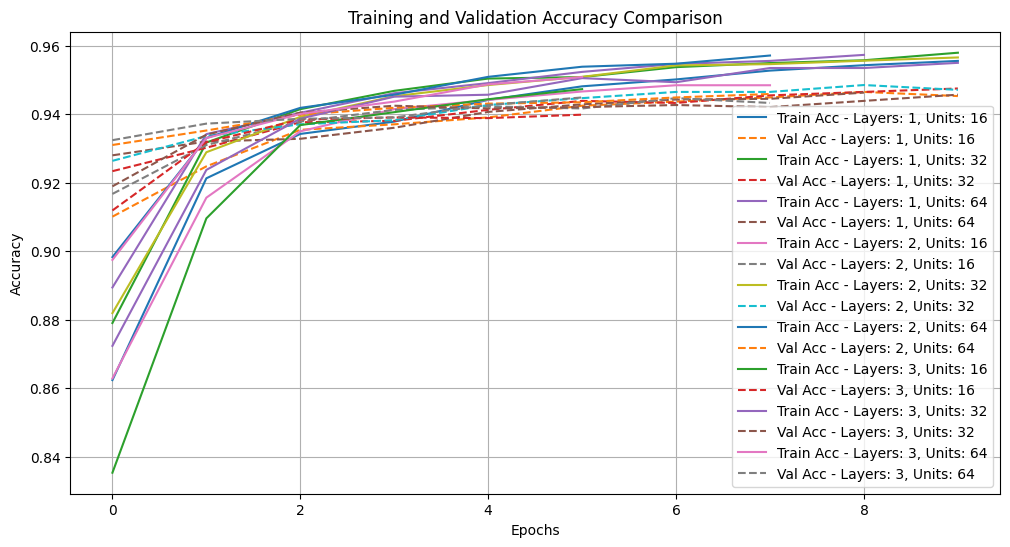

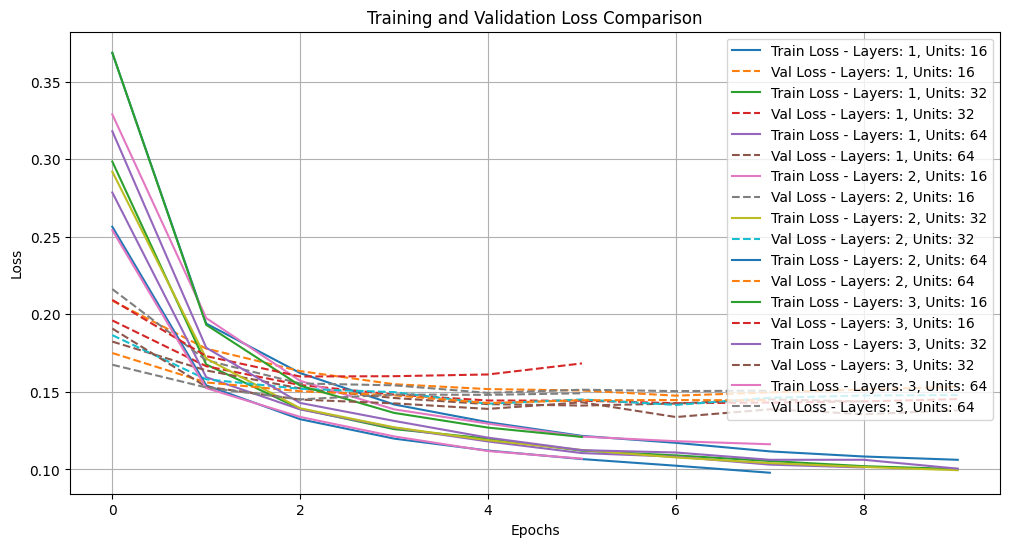


Model Performance Summary:
Model 1 - 1 layers, 16 units:
  Validation Accuracy: 0.9437
  Final Epochs: 10

Model 2 - 1 layers, 32 units:
  Validation Accuracy: 0.9433
  Final Epochs: 10

Model 3 - 1 layers, 64 units:
  Validation Accuracy: 0.9429
  Final Epochs: 9

Model 4 - 2 layers, 16 units:
  Validation Accuracy: 0.9423
  Final Epochs: 8

Model 5 - 2 layers, 32 units:
  Validation Accuracy: 0.9465
  Final Epochs: 10

Model 6 - 2 layers, 64 units:
  Validation Accuracy: 0.9431
  Final Epochs: 8

Model 7 - 3 layers, 16 units:
  Validation Accuracy: 0.9384
  Final Epochs: 6

Model 8 - 3 layers, 32 units:
  Validation Accuracy: 0.9427
  Final Epochs: 10

Model 9 - 3 layers, 64 units:
  Validation Accuracy: 0.9386
  Final Epochs: 6



In [44]:
# Plot train/validation accuracy.

plt.figure(figsize=(12, 6))
for i, result in enumerate(histories_base_s3):
    config = result['config']
    config_str = f"Layers: {config['layers']}, Units: {config['units']}"
    history_obj = result['history']
    
    plt.plot(history_obj.history['accuracy'], label=f"Train Acc - {config_str}")
    plt.plot(history_obj.history['val_accuracy'], linestyle='--', label=f"Val Acc - {config_str}")

plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot train/validation loss
plt.figure(figsize=(12, 6))
for i, result in enumerate(histories_base_s3):
    config = result['config']
    config_str = f"Layers: {config['layers']}, Units: {config['units']}"
    history_obj = result['history']
    
    plt.plot(history_obj.history['loss'], label=f"Train Loss - {config_str}")
    plt.plot(history_obj.history['val_loss'], linestyle='--', label=f"Val Loss - {config_str}")

plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Print numerical summary
print("\nModel Performance Summary:")
print("=" * 60)
for i, result in enumerate(histories_base_s3):
    config = result['config']
    print(f"Model {i+1} - {config['layers']} layers, {config['units']} units:")
    print(f"  Validation Accuracy: {result['val_accuracy']:.4f}")
    print(f"  Final Epochs: {len(result['history'].history['loss'])}")
    print()

In [45]:
# @tittle Model Evaluation

# --- Evaluation Function ---
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

def evaluate_trained_models(models, hist_metrics, X_test, y_test, 
                           class_names=None, verbose=True, return_curves=False):
    """
    Comprehensive model evaluation function optimized for imbalanced datasets
    
    Parameters:
    -----------
    models : list
        List of trained Keras models
    hist_metrics : list
        List of training history and config data
    X_test : array-like
        Test features
    y_test : array-like
        Test labels
    class_names : list, optional
        Names of classes for better reporting
    verbose : bool
        Print detailed results
    return_curves : bool
        Whether to return ROC and PR curve data
    
    Returns:
    --------
    results : list
        Comprehensive evaluation results for each model
    """
    
    # Set seeds for reproducible evaluation
    np.random.seed(42)
    
    results_base_s3 = []
    n_classes = len(np.unique(y_test))
    is_binary = n_classes == 2
    
    if verbose:
        print("="*80)
        print(f"EVALUATING {len(models)} MODELS ON TEST SET")
        print(f"Dataset: {len(y_test)} samples, {n_classes} classes")
        if is_binary:
            class_dist = np.bincount(y_test)
            print(f"Class distribution: {class_dist[0]}:{class_dist[1]} ({class_dist[1]/len(y_test)*100:.1f}% positive)")
        print("="*80)
    
    for i, (model, history_data) in enumerate(zip(models, hist_metrics)):
        config = history_data['config']
        model_name = f"Model_{i+1}_{config['layers']}L_{config['units']}U"
        
        if verbose:
            print(f"\n{model_name}")
            print("-" * 50)
        
        try:
            # Get predictions - CONSISTENT APPROACH
            y_pred_prob = model.predict(X_test, verbose=0)
            
            # FIXED: Consistent probability extraction
            if y_pred_prob.shape[1] > 1:  # Multi-class output
                y_pred_class = np.argmax(y_pred_prob, axis=1)
                if is_binary:
                    # For binary classification, use probability of positive class (class 1)
                    y_prob_positive = y_pred_prob[:, 1]
                else:
                    y_prob_positive = y_pred_prob  # Keep all probabilities for multi-class
            else:  # Single output (sigmoid activation)
                y_pred_prob = y_pred_prob.flatten()
                y_pred_class = (y_pred_prob > 0.5).astype(int)
                y_prob_positive = y_pred_prob
            
            # Basic metrics
            test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
            
            # Classification metrics
            if is_binary:
                # Binary classification metrics
                precision = precision_score(y_test, y_pred_class, zero_division=0)
                recall = recall_score(y_test, y_pred_class, zero_division=0)
                f1 = f1_score(y_test, y_pred_class, zero_division=0)
                
                # Class-specific metrics
                precision_per_class = precision_score(y_test, y_pred_class, average=None, zero_division=0)
                recall_per_class = recall_score(y_test, y_pred_class, average=None, zero_division=0)
                f1_per_class = f1_score(y_test, y_pred_class, average=None, zero_division=0)
                
                # FIXED: Use consistent function for ROC-AUC calculation
                roc_auc = roc_auc_score(y_test, y_prob_positive)
                
                # Alternative calculation using roc_curve + auc (should match)
                fpr, tpr, _ = roc_curve(y_test, y_prob_positive)
                roc_auc_manual = auc(fpr, tpr)
                
                # Precision-Recall AUC (better for imbalanced data)
                precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_positive)
                pr_auc = auc(recall_curve, precision_curve)
                
                # Confusion matrix components
                cm = confusion_matrix(y_test, y_pred_class)
                tn, fp, fn, tp = cm.ravel()
                
                # Additional metrics for imbalanced data
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Same as recall
                
                # Matthews Correlation Coefficient (good for imbalanced data)
                mcc = ((tp * tn) - (fp * fn)) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) if ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) > 0 else 0
                
                # Balanced accuracy
                balanced_accuracy = (sensitivity + specificity) / 2
            else:
                # Multi-class metrics
                precision = precision_score(y_test, y_pred_class, average='weighted', zero_division=0)
                recall = recall_score(y_test, y_pred_class, average='weighted', zero_division=0)
                f1 = f1_score(y_test, y_pred_class, average='weighted', zero_division=0)
                
                precision_per_class = precision_score(y_test, y_pred_class, average=None, zero_division=0)
                recall_per_class = recall_score(y_test, y_pred_class, average=None, zero_division=0)
                f1_per_class = f1_score(y_test, y_pred_class, average=None, zero_division=0)
                
                # Multi-class ROC-AUC (one-vs-rest)
                roc_auc = roc_auc_score(y_test, y_prob_positive, multi_class='ovr', average='weighted')
                roc_auc_manual = roc_auc  # For consistency
                pr_auc = np.nan  # Not directly applicable to multi-class
                
                cm = confusion_matrix(y_test, y_pred_class)
                specificity = sensitivity = mcc = balanced_accuracy = np.nan
            
            # Store results
            result = {
                'model_name': model_name,
                'model': model,
                'config': config,
                
                # Test performance
                'test_loss': test_loss,
                'test_accuracy': test_accuracy,
                'balanced_accuracy': balanced_accuracy,
                
                # Main classification metrics
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'roc_auc': roc_auc,
                'roc_auc_manual': roc_auc_manual,  # For verification
                'pr_auc': pr_auc,  # Better than ROC-AUC for imbalanced data
                
                # Per-class metrics
                'precision_per_class': precision_per_class,
                'recall_per_class': recall_per_class,
                'f1_per_class': f1_per_class,
                
                # Imbalanced data specific metrics
                'specificity': specificity,
                'sensitivity': sensitivity,
                'mcc': mcc,
                
                # Predictions and probabilities - STORED CONSISTENTLY
                'y_pred_prob': y_prob_positive,  # Always the positive class prob for binary
                'y_pred_prob_full': y_pred_prob,  # Full probability matrix
                'y_pred_class': y_pred_class,
                'confusion_matrix': cm,
                
                # Training history metrics
                'val_accuracy': history_data.get('val_accuracy', np.nan),
                'val_loss': history_data.get('val_loss', np.nan),
                'train_accuracy': history_data.get('train_accuracy', np.nan),
                'train_loss': history_data.get('train_loss', np.nan),
            }
            
            # Add curve data if requested
            if return_curves and is_binary:
                fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_positive)
                precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_prob_positive)
                
                result.update({
                    'roc_curve': {'fpr': fpr, 'tpr': tpr, 'thresholds': roc_thresholds},
                    'pr_curve': {'precision': precision_curve, 'recall': recall_curve, 'thresholds': pr_thresholds}
                })
            
            results_base_s3.append(result)
            
            # Verbose output
            if verbose:
                print(f"Core Metrics:")
                print(f"Accuracy: {test_accuracy:.4f} | Balanced Acc: {balanced_accuracy:.4f}")
                print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
                print(f"AUC Scores:")
                print(f" ROC-AUC: {roc_auc:.4f} | ROC-AUC (manual): {roc_auc_manual:.4f} | PR-AUC: {pr_auc:.4f}")
                
                if is_binary:
                    print(f"Imbalanced Metrics:")
                    print(f"Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}")
                    print(f"MCC: {mcc:.4f}")
                    print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
                
                print(f"Training Performance:")
                # FIXED: Proper conditional formatting
                train_loss_val = history_data.get('train_loss', np.nan)
                val_loss_val = history_data.get('val_loss', np.nan)
                
                if isinstance(train_loss_val, (int, float)) and not np.isnan(train_loss_val):
                    print(f"   Train Loss: {train_loss_val:.4f}")
                else:
                    print(f"   Train Loss: N/A")
                    
                if isinstance(val_loss_val, (int, float)) and not np.isnan(val_loss_val):
                    print(f"   Val Loss: {val_loss_val:.4f}")
                else:
                    print(f"   Val Loss: N/A")
                
        except Exception as e:
            print(f"Error evaluating {model_name}: {str(e)}")
            continue
    
    if verbose:
        print("\n" + "="*80)
        print("EVALUATION SUMMARY")
        print("="*80)
        
        # Create summary DataFrame
        summary_data_base_s3 = []
        for r in results_base_s3:
            summary_data_base_s3.append({
                'Model': r['model_name'],
                'ROC_AUC': r['roc_auc'],
                'ROC_AUC_Manual': r['roc_auc_manual'],
                'PR_AUC': r['pr_auc'],
                'F1': r['f1'],
                'Bal_Acc': r['balanced_accuracy'],
                'MCC': r.get('mcc', np.nan)
            })
        
        summary_df_base_s3 = pd.DataFrame(summary_data_base_s3)
        
        positive_ratio = np.mean(y_test)
        if positive_ratio < 0.4:  # Positives are minority
            sort_col = 'PR_AUC'   # Focus on positive class performance
        elif positive_ratio > 0.6:  # Positives are majority  
            sort_col = 'ROC_AUC' # Focus on negative class performance
        else:
            sort_col = 'ROC_AUC'
        
        # Sort by ROC-AUC (or PR-AUC for heavily imbalanced data)
        summary_df_base_s3 = summary_df_base_s3.sort_values(sort_col, ascending=False)
        
        print(summary_df_base_s3.round(4).to_string(index=False))
        print(f"\nBest model by {sort_col}: {summary_df_base_s3.iloc[0]['Model']}")
        
        # Save summary to CSV - FIXED PATH: Save in current directory
        output_path = 'comparison_neural_networks_all_stages.csv'
        summary_df_base_s3.to_csv(output_path, index=False)
        print(f"\nSummary saved to: {output_path}")
    
    return results_base_s3

# Run evaluation
test_results_s3_base = evaluate_trained_models(
    models_base_s3, 
    histories_base_s3, 
    X_test_scaled_s3, 
    y_test_s3, 
    verbose=True, 
    return_curves=True
)

EVALUATING 9 MODELS ON TEST SET
Dataset: 3976 samples, 2 classes
Class distribution: 586:3390 (85.3% positive)

Model_1_1L_16U
--------------------------------------------------
Core Metrics:
Accuracy: 0.9505 | Balanced Acc: 0.9166
Precision: 0.9770 | Recall: 0.9646 | F1: 0.9708
AUC Scores:
 ROC-AUC: 0.9814 | ROC-AUC (manual): 0.9814 | PR-AUC: 0.9968
Imbalanced Metrics:
Sensitivity: 0.9646 | Specificity: 0.8686
MCC: 0.8094
Confusion Matrix: TN=509, FP=77, FN=120, TP=3270
Training Performance:
   Train Loss: 0.1027
   Val Loss: 0.1476

Model_2_1L_32U
--------------------------------------------------
Core Metrics:
Accuracy: 0.9499 | Balanced Acc: 0.9212
Precision: 0.9790 | Recall: 0.9619 | F1: 0.9704
AUC Scores:
 ROC-AUC: 0.9830 | ROC-AUC (manual): 0.9830 | PR-AUC: 0.9971
Imbalanced Metrics:
Sensitivity: 0.9619 | Specificity: 0.8805
MCC: 0.8101
Confusion Matrix: TN=516, FP=70, FN=129, TP=3261
Training Performance:
   Train Loss: 0.0966
   Val Loss: 0.1427

Model_3_1L_64U
---------------

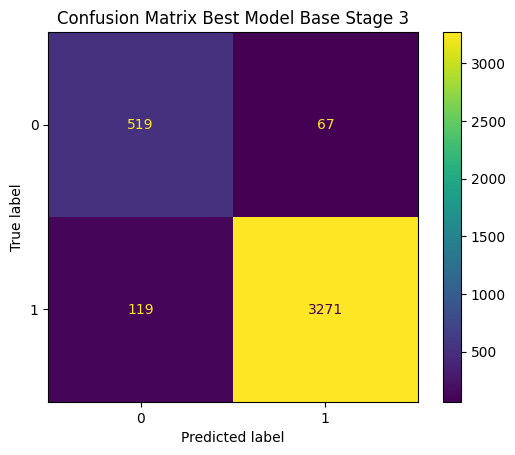

In [46]:
# Assuming test_results_s3_base is a list of dictionaries containing model results
for result in test_results_s3_base:
    # Check if this is the specific model we want
    if result.get('model_name') == 'Model_5_2L_32U' and 'confusion_matrix' in result:
        disp = ConfusionMatrixDisplay(confusion_matrix=result['confusion_matrix'])
        disp.plot()
        plt.title(f"Confusion Matrix Best Model Base Stage 3")
        plt.show()

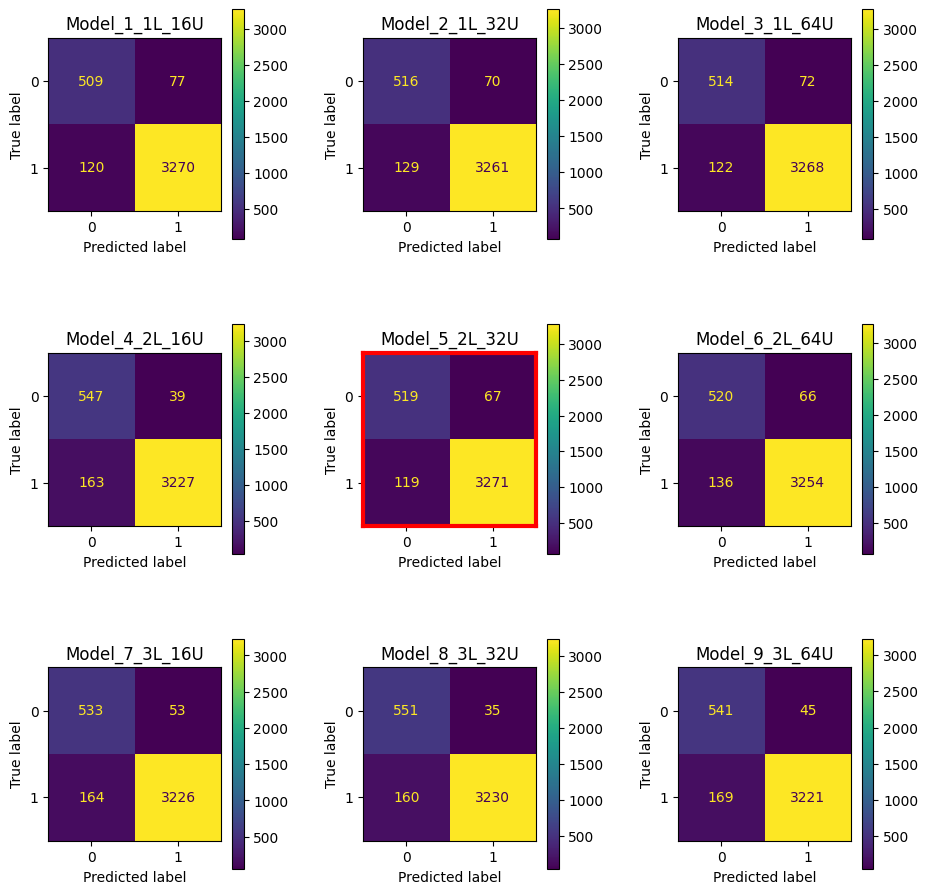

In [47]:
# Display all the Baseline Models Tested

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.tight_layout(pad=4.0)

# Flatten the axes array for easier iteration
axes = axes.ravel()

# Counter for the current subplot
plot_idx = 0

for result in test_results_s3_base:
    # Stop if we've filled all 9 subplots
    if plot_idx >= 9:
        break
        
    # Check if this is the specific model we want
    if result.get('model_name') and 'confusion_matrix' in result:
        disp = ConfusionMatrixDisplay(confusion_matrix=result['confusion_matrix'])
        disp.plot(ax=axes[plot_idx])
        axes[plot_idx].set_title(f"{result['model_name']}")
        
        # Add red border if this is Model_5_2L_32U
        if result['model_name'] == 'Model_5_2L_32U':
            for spine in axes[plot_idx].spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)
        
        plot_idx += 1

# Hide any remaining empty subplots
for i in range(plot_idx, 9):
    axes[i].axis('off')

plt.show()

In [48]:
# Sorting models based on best metric.
positive_ratio = np.mean(y_test_s3)
if positive_ratio < 0.5:  # Positives are minority
    sort_col = 'pr_auc'   # Focus on positive class performance
    print(f"Positive class is minority ({positive_ratio:.2%}), sorting by PR-AUC")
else:  # Positives are majority
    sort_col = 'roc_auc'  # Focus on overall performance
    print(f"Positive class is majority ({positive_ratio:.2%}), sorting by ROC-AUC")

sorted_auc_base_s3 = sorted(test_results_s3_base, key=lambda x: x.get(sort_col, 0), reverse=True)


Positive class is majority (85.26%), sorting by ROC-AUC


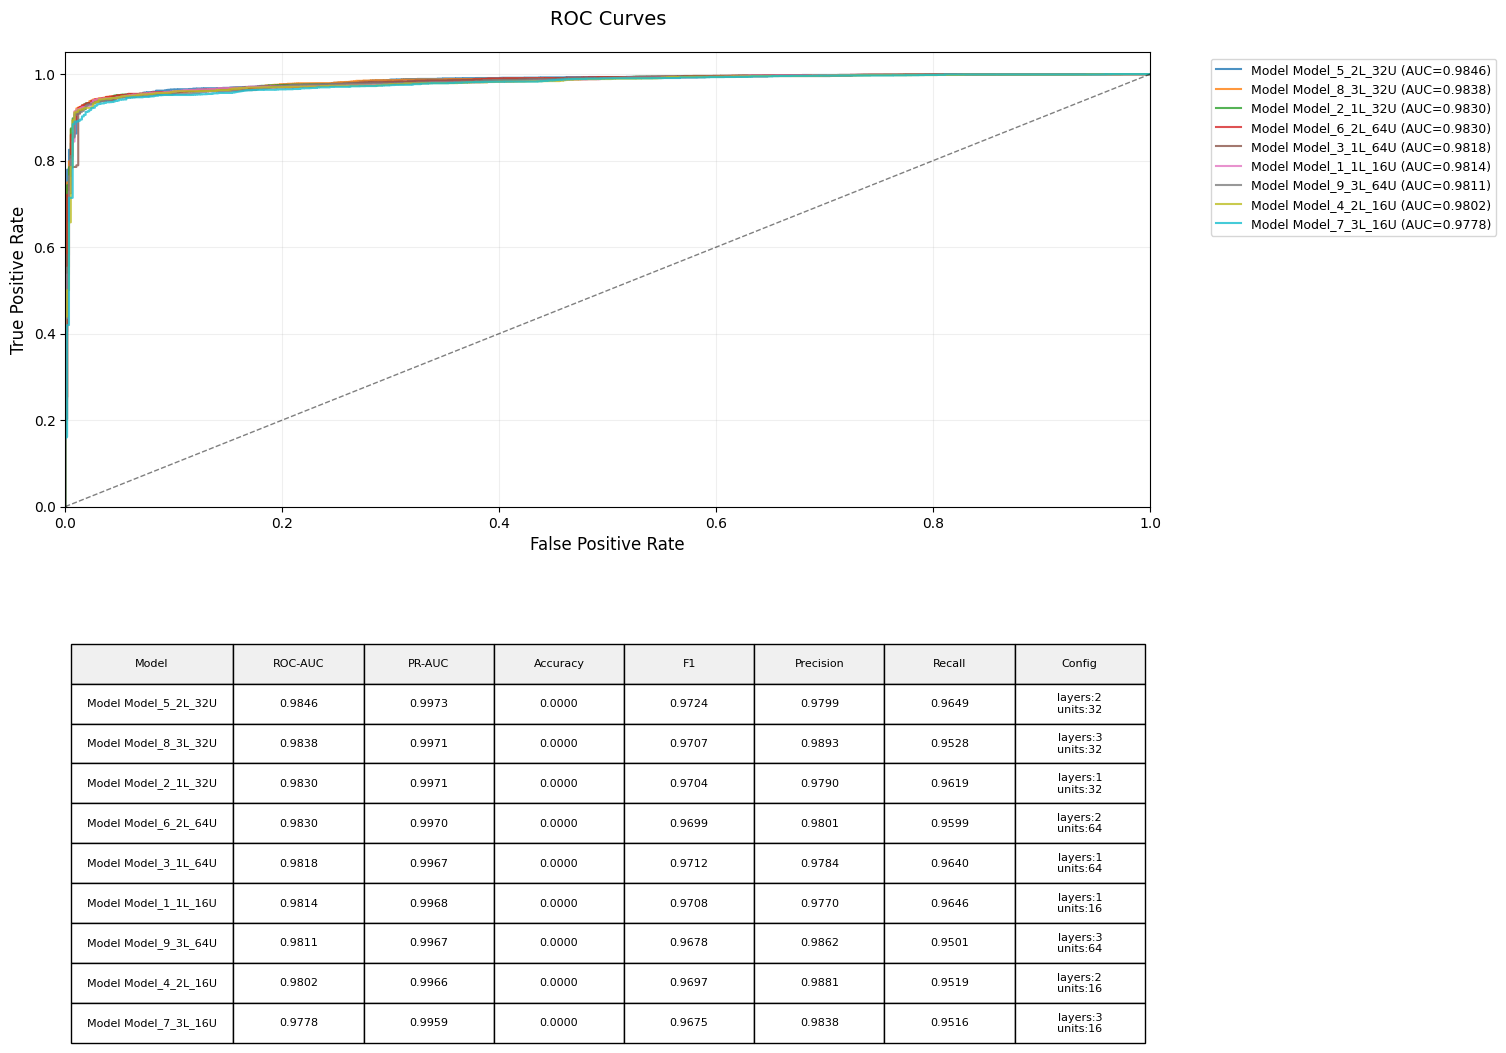

In [49]:
# @tittle ROC Curve for Learning Rate and Activation Function

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

def plot_roc_curves(test_results, X_test=None, y_test=None):
    """
    Enhanced ROC curve visualization with model names in legend and table,
    including both ROC-AUC and PR-AUC metrics.
    FIXED: Now uses the same probability extraction method as evaluation function
    """
    plt.figure(figsize=(14, 12))  # Increased figure size for two plots
    
    # Create color palette
    colors = plt.cm.tab10(np.linspace(0, 1, len(test_results)))
    
    # Create subplots with better layout
    ax1 = plt.subplot2grid((10, 2), (0, 0), colspan=2, rowspan=5)  # ROC plot area
    ax2 = plt.subplot2grid((10, 2), (7, 0), colspan=2, rowspan=3)  # Table area
    ax2.axis('off')
    
    # Prepare table data
    table_data = []
    col_labels = ['Model', 'ROC-AUC', 'PR-AUC', 'Accuracy', 'F1', 'Precision', 'Recall', 'Config']
    
    for i, res in enumerate(test_results):
        try:
            # Get model index and config
            model_idx = res.get('model_name', i)
            config = res['config']
            
            # FIXED: Use stored probabilities from evaluation function
            # This ensures consistency between evaluation and plotting
            if 'y_pred_prob' in res and res['y_pred_prob'] is not None:
                y_score = res['y_pred_prob']  # This is already the positive class probability
            else:
                # Fallback: re-predict if not stored (not recommended)
                print(f"Warning: Re-predicting for model {model_idx} - may cause inconsistency")
                if 'model' in res:
                    y_pred_prob = res['model'].predict(X_test, verbose=0)
                    if y_pred_prob.shape[1] > 1:
                        y_score = y_pred_prob[:, 1]
                    else:
                        y_score = y_pred_prob.flatten()
                else:
                    raise ValueError("No prediction data or model found in results")
            
            # Handle binary vs multi-class
            n_classes = len(np.unique(y_test))
            if n_classes == 2:  # Binary classification
                # FIXED: Use the SAME calculation method as evaluation function
                # Use roc_auc_score for consistency
                roc_auc = roc_auc_score(y_test, y_score)
                
                # Also calculate using roc_curve + auc (should be identical)
                fpr, tpr, _ = roc_curve(y_test, y_score)
                roc_auc_manual = auc(fpr, tpr)
                
                # Verify they match (within floating point precision)
                if abs(roc_auc - roc_auc_manual) > 1e-10:
                    print(f"Warning: ROC-AUC calculation mismatch for model {model_idx}")
                    print(f"  roc_auc_score: {roc_auc:.10f}")
                    print(f"  manual calc:   {roc_auc_manual:.10f}")
                
                # Use the same method as evaluation function
                pr_auc = average_precision_score(y_test, y_score)
                
                # Plot ROC curve
                ax1.plot(fpr, tpr, color=colors[i], lw=1.5, alpha=0.8,
                        label=f"Model {model_idx} (AUC={roc_auc:.4f})")
                
            else:  # Multi-class - kept same logic but using stored probabilities
                # Use stored full probability matrix
                y_prob = res.get('y_pred_prob_full', res.get('y_pred_prob'))
                if y_prob is None:
                    raise ValueError("No multi-class probability data found")
                
                # One-vs-Rest approach
                fpr, tpr, roc_auc_dict = {}, {}, {}
                
                for class_idx in range(n_classes):
                    fpr[class_idx], tpr[class_idx], _ = roc_curve((y_test == class_idx).astype(int), 
                                                               y_prob[:, class_idx])
                    roc_auc_dict[class_idx] = auc(fpr[class_idx], tpr[class_idx])
                
                # Micro-average metrics
                fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_prob.ravel())
                roc_auc = auc(fpr["micro"], tpr["micro"])
                
                precision, recall, _ = precision_recall_curve(y_test.ravel(), y_prob.ravel())
                pr_auc = auc(recall, precision)
                
                # Plot micro-average curves
                ax1.plot(fpr["micro"], tpr["micro"], color=colors[i], lw=1.5, alpha=0.8,
                        label=f"Model {model_idx} (Micro ROC AUC={roc_auc:.4f})")
            
            # Format config for display
            config_clean = {k: v for k, v in config.items() if k != 'model'}
            config_str = "\n".join([f"{k}:{v:.4f}" if isinstance(v, (float, np.floating)) 
                                  else f"{k}:{v}" 
                                  for k, v in config_clean.items()])
            
            # FIXED: Use the SAME values from evaluation results
            table_data.append([
                f"Model {model_idx}",
                f"{res.get('roc_auc', roc_auc):.4f}",  # Use stored value if available
                f"{res.get('pr_auc', pr_auc):.4f}",    # Use stored value if available
                f"{res.get('accuracy', 0):.4f}",
                f"{res.get('f1', 0):.4f}",
                f"{res.get('precision', 0):.4f}",
                f"{res.get('recall', 0):.4f}",
                config_str
            ])
            
        except Exception as e:
            print(f"Error processing model {i}: {str(e)}")
            continue
    
    # Format ROC plot
    ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title('ROC Curves', fontsize=14, pad=20)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax1.grid(alpha=0.2)
    
    # Create table with better formatting
    if table_data:
        table = ax2.table(
            cellText=table_data,
            colLabels=col_labels,
            loc='center',
            cellLoc='center',
            colColours=['#f0f0f0']*len(col_labels))
        
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        
        table.scale(1, 1.5)  # Increased height scaling for two-line cells
        
        # Set specific column widths and allow text wrapping
        for i in range(len(col_labels)):
            for j in range(len(table_data) + 1):  # +1 for header row
                cell = table[(j, i)]
                if i == 0:  # Config column
                    cell.set_width(0.15)  # Wider for config column
                    cell.set_height(0.15)  # Taller for two-line text
                else:
                    cell.set_width(0.12)
                    cell.set_height(0.15)
    
   
    plt.show()

# Usage
plot_roc_curves(sorted_auc_base_s3, X_test=X_test_scaled_s3, y_test=y_test_s3)


#### Note: The models seem to be overfitting, considering the Loss Curves and the very high ROC_AUC scores. Therefore, I will apply L1 and L2 regularization to assess whether the overfitting can be reduced without having to manipulate the data.

### Model 5: 2 layers and 32 units shows highest ROC-AUC score and the best combination of metrics compared to all other models. 

In [50]:
# Suppress TensorFlow warnings and logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress all TF logs (0=all, 1=info, 2=warning, 3=error)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN optimizations warnings
warnings.filterwarnings('ignore')

# Additional TensorFlow logging suppression
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

def set_global_determinism(seed):
    """Set seeds for reproducible results"""
    tf.random.set_seed(seed)
    np.random.seed(seed)

def create_model_tuning(input_dim, output_dim, layers=2, units=32, dropout=0.2, batch_size=16,
                       lr=0.001, optimizer='adam', seed=42,
                       l1_reg=0.0, l2_reg=0.0):
    """Create a deterministic neural network model with L1/L2 regularization"""
    # Reset seeds before each model creation
    tf.random.set_seed(seed)
    np.random.seed(seed)
    
    # Create regularization object
    kernel_regularizer = regularizers.L1L2(l1=l1_reg, l2=l2_reg) if (l1_reg > 0 or l2_reg > 0) else None
    
    model = Sequential(name=f"model_{layers}L_{units}U")
    model.add(InputLayer(shape=(input_dim,)))
    
    for _ in range(layers):
        model.add(Dense(units, activation='relu', 
                       kernel_regularizer=kernel_regularizer,
                       kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed),
                       bias_initializer=tf.keras.initializers.Zeros()))
        model.add(Dropout(dropout, seed=seed))
    
    model.add(Dense(output_dim, activation='softmax',
                   kernel_regularizer=kernel_regularizer,
                   kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed),
                   bias_initializer=tf.keras.initializers.Zeros()))
    
    # Choose optimizer
    if optimizer.lower() == 'adam':
        opt = Adam(learning_rate=lr)
    elif optimizer.lower() == 'rmsprop':
        opt = RMSprop(learning_rate=lr)
    else:
        opt = Adam(learning_rate=lr)  # default
    
    model.compile(optimizer=opt,
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return model

# Get dimensions (assuming X_train, y_train are defined)
input_dim = X_train_scaled_s3.shape[1]
output_dim = len(np.unique(y_train_s3))

# Hyperparameter grid with L1/L2 regularization options
hyperparameter_config = {
    'dropout': [0.2], 
    'lr': [0.001],
    'optimizer': ['adam'],
    'batch_size': [16, 32],
    'l1_reg': [0.01, 0.001],  # L1 regularization strengths
    'l2_reg': [0.01, 0.001]   # L2 regularization strengths
}
models_tuning_s3 = []
histories_tuning_s3 = []

# Generate all combinations of hyperparameters
keys, values = zip(*hyperparameter_config.items())
configs = [dict(zip(keys, v)) for v in product(*values)]

# Initialize progress bar
progress_bar = tqdm(configs, desc="Hyperparameter Tuning", unit="model")

for i, config in enumerate(progress_bar):
    # Update progress bar description with current config
    short_desc = (f"do:{config['dropout']} lr:{config['lr']} opt:{config['optimizer']} "
                 f"bs:{config['batch_size']} L1:{config['l1_reg']} L2:{config['l2_reg']}")
    progress_bar.set_postfix(config=short_desc)
    
    # Set unique but deterministic seed for each model
    model_seed = 42 + i
    set_global_determinism(model_seed)
    
    # Clear session and memory
    tf.keras.backend.clear_session()
    gc.collect()
    
    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=3, 
                              restore_best_weights=True, verbose=0)
    
    # Create model with current config (excluding batch_size which is for training)
    model_config = {k: v for k, v in config.items() if k != 'batch_size'}
    model_tuning_s3 = create_model_tuning(input_dim, output_dim, seed=model_seed, **model_config)
    
    # Train model (NON-VERBOSE)
    history_tuning_s3 = model_tuning_s3.fit(
        X_train_scaled_s3, y_train_s3,
        validation_data=(X_val_scaled_s3, y_val_s3),
        batch_size=config['batch_size'],
        epochs=5,
        callbacks=[early_stop],
        shuffle=True,  # Deterministic due to seed
        verbose=0  # Silent training
    )
    
    # Evaluate model (NON-VERBOSE)
    val_loss_tuning_s3, val_acc_tuning_s3 = model_tuning_s3.evaluate(X_val_scaled_s3, y_val_s3, verbose=0)
    
    
    # Store results
    models_tuning_s3.append(model_tuning_s3)
    histories_tuning_s3.append({
        "config": config,
        "model": model_tuning_s3,
        "val_loss": val_loss_tuning_s3,
        "val_accuracy": val_acc_tuning_s3,
        "history": history_tuning_s3,
        "seed": model_seed
    })
    
    # Clean up
    gc.collect()

# Close progress bar
progress_bar.close()

print(f"Hyperparameter tuning completed. Trained {len(models_tuning_s3)} models.")
print('Models: models_tuning_s3, Histories: histories_tuning_s3')


Hyperparameter Tuning:   0%|          | 0/8 [00:00<?, ?model/s]

Hyperparameter Tuning: 100%|██████████| 8/8 [00:35<00:00,  4.45s/model, config=do:0.2 lr:0.001 opt:adam bs:32 L1:0.001 L2:0.001]

Hyperparameter tuning completed. Trained 8 models.
Models: models_tuning_s3, Histories: histories_tuning_s3


In [51]:
# Because there are too many models, sort and select top 15 Accuracy scores.
sorted_acc_tuning_s3 = sorted(histories_tuning_s3, key=lambda x: x['val_accuracy'], reverse=True)
top_acc_tuning_s3 = sorted_acc_tuning_s3[:15]

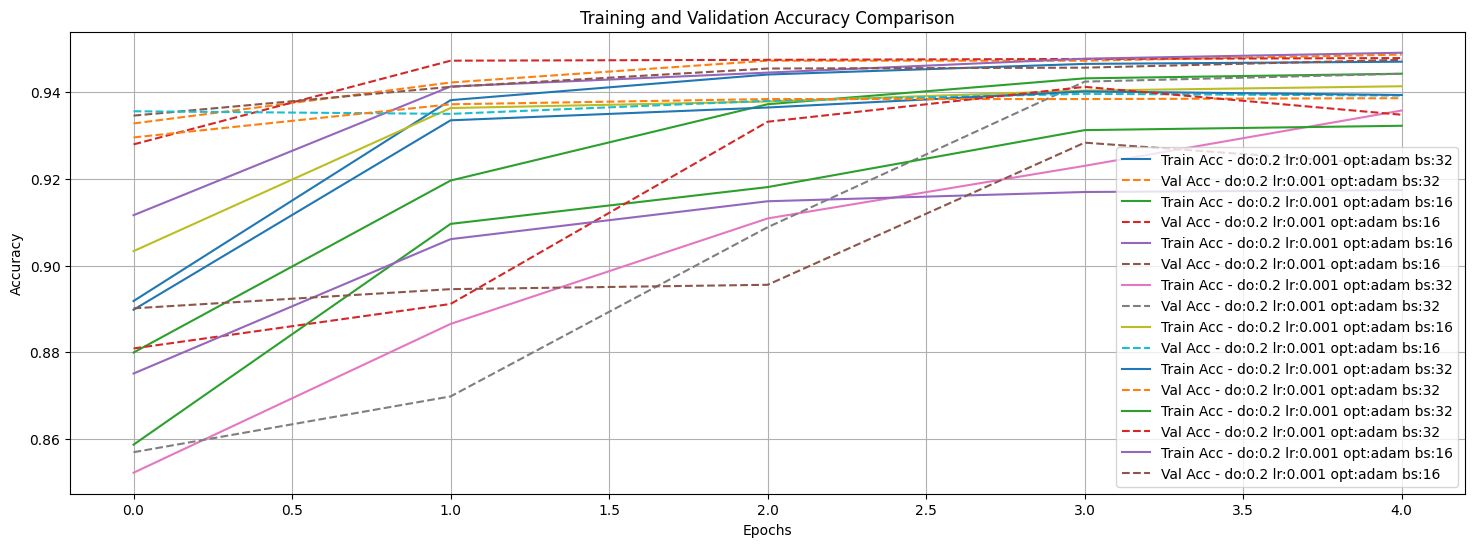

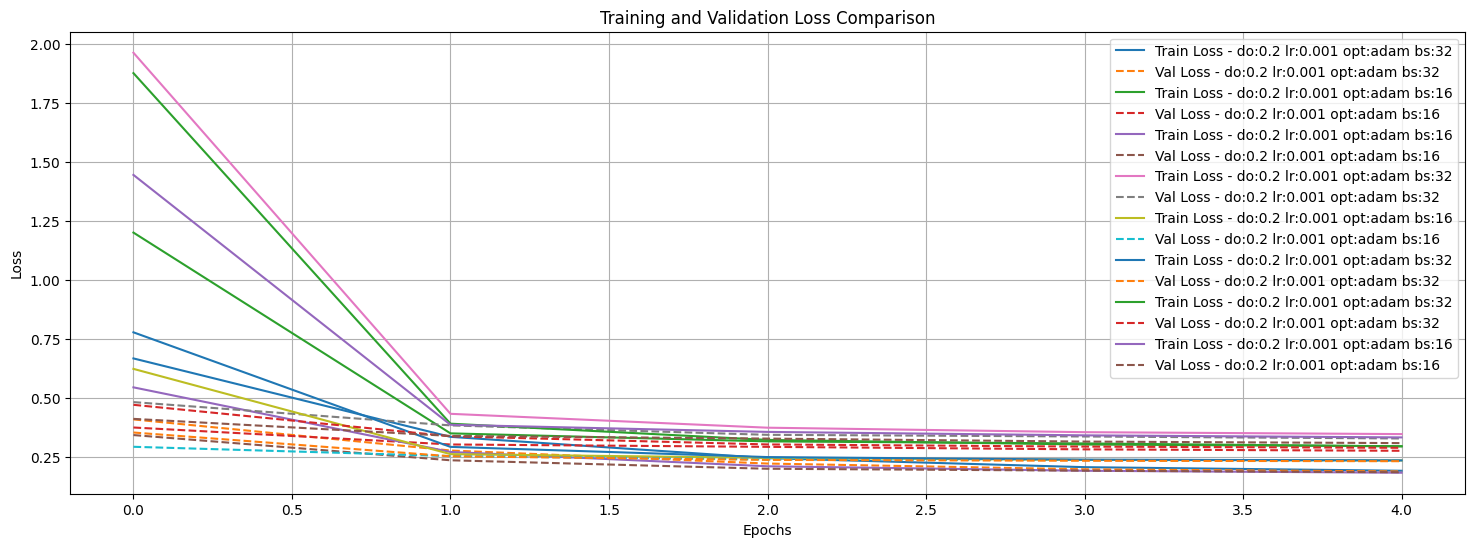

In [52]:
# Plot train/validation accuracy for best models
plt.figure(figsize=(18, 6))
for i, result in enumerate(top_acc_tuning_s3):
    config = result['config']
    config_str = f"do:{config['dropout']} lr:{config['lr']} opt:{config['optimizer']} bs:{config['batch_size']}"
    history_obj = result['history']
    
    plt.plot(history_obj.history['accuracy'], label=f"Train Acc - {config_str}")
    plt.plot(history_obj.history['val_accuracy'], linestyle='--', label=f"Val Acc - {config_str}")

plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot train/validation loss
plt.figure(figsize=(18, 6))
for i, result in enumerate(top_acc_tuning_s3):
    config = result['config']
    config_str = f"do:{config['dropout']} lr:{config['lr']} opt:{config['optimizer']} bs:{config['batch_size']}"
    history_obj = result['history']
    
    plt.plot(history_obj.history['loss'], label=f"Train Loss - {config_str}")
    plt.plot(history_obj.history['val_loss'], linestyle='--', label=f"Val Loss - {config_str}")

plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


### Note: The 2 layers and 32 units architecture seems to be too much for this dataset. The model is learning very quickly and based on our tuning parameters, the model is performing very well, without overfitting. I will try with a simpler architecture.

In [53]:
# Model with 1 layer and 16 Units

# Suppress TensorFlow warnings and logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress all TF logs (0=all, 1=info, 2=warning, 3=error)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN optimizations warnings
warnings.filterwarnings('ignore')

# Additional TensorFlow logging suppression
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

def set_global_determinism(seed):
    """Set seeds for reproducible results"""
    tf.random.set_seed(seed)
    np.random.seed(seed)

def create_model_tuning(input_dim, output_dim, layers=1, units=32, dropout=0.2, batch_size=16,
                       lr=0.001, optimizer='adam', seed=42,
                       l1_reg=0.0, l2_reg=0.0):
    """Create a deterministic neural network model with L1/L2 regularization"""
    # Reset seeds before each model creation
    tf.random.set_seed(seed)
    np.random.seed(seed)
    
    # Create regularization object
    kernel_regularizer = regularizers.L1L2(l1=l1_reg, l2=l2_reg) if (l1_reg > 0 or l2_reg > 0) else None
    
    model = Sequential(name=f"model_{layers}L_{units}U")
    model.add(InputLayer(shape=(input_dim,)))
    
    for _ in range(layers):
        model.add(Dense(units, activation='relu', 
                       kernel_regularizer=kernel_regularizer,
                       kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed),
                       bias_initializer=tf.keras.initializers.Zeros()))
        model.add(Dropout(dropout, seed=seed))
    
    model.add(Dense(output_dim, activation='softmax',
                   kernel_regularizer=kernel_regularizer,
                   kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed),
                   bias_initializer=tf.keras.initializers.Zeros()))
    
    # Choose optimizer
    if optimizer.lower() == 'adam':
        opt = Adam(learning_rate=lr)
    elif optimizer.lower() == 'rmsprop':
        opt = RMSprop(learning_rate=lr)
    else:
        opt = Adam(learning_rate=lr)  # default
    
    model.compile(optimizer=opt,
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return model

# Get dimensions (assuming X_train, y_train are defined)
input_dim = X_train_scaled_s3.shape[1]
output_dim = len(np.unique(y_train_s3))

# Hyperparameter grid with L1/L2 regularization options
hyperparameter_config = {
    'dropout': [0.2], 
    'lr': [0.001],
    'optimizer': ['adam'],
    'batch_size': [16, 32],
    'l1_reg': [0.01, 0.001],  # L1 regularization strengths
    'l2_reg': [0.01, 0.001]   # L2 regularization strengths
}
models_tuning_s3 = []
histories_tuning_s3 = []

# Generate all combinations of hyperparameters
keys, values = zip(*hyperparameter_config.items())
configs = [dict(zip(keys, v)) for v in product(*values)]

# Initialize progress bar
progress_bar = tqdm(configs, desc="Hyperparameter Tuning", unit="model")

for i, config in enumerate(progress_bar):
    # Update progress bar description with current config
    short_desc = (f"do:{config['dropout']} lr:{config['lr']} opt:{config['optimizer']} "
                 f"bs:{config['batch_size']} L1:{config['l1_reg']} L2:{config['l2_reg']}")
    progress_bar.set_postfix(config=short_desc)
    
    # Set unique but deterministic seed for each model
    model_seed = 42 + i
    set_global_determinism(model_seed)
    
    # Clear session and memory
    tf.keras.backend.clear_session()
    gc.collect()
    
    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=3, 
                              restore_best_weights=True, verbose=0)
    
    # Create model with current config (excluding batch_size which is for training)
    model_config = {k: v for k, v in config.items() if k != 'batch_size'}
    model_tuning_s3 = create_model_tuning(input_dim, output_dim, seed=model_seed, **model_config)
    
    # Train model (NON-VERBOSE)
    history_tuning_s3 = model_tuning_s3.fit(
        X_train_scaled_s3, y_train_s3,
        validation_data=(X_val_scaled_s3, y_val_s3),
        batch_size=config['batch_size'],
        epochs=5,
        callbacks=[early_stop],
        shuffle=True,  # Deterministic due to seed
        verbose=0  # Silent training
    )
    
    # Evaluate model (NON-VERBOSE)
    val_loss_tuning_s3, val_acc_tuning_s3 = model_tuning_s3.evaluate(X_val_scaled_s3, y_val_s3, verbose=0)
    
    
    # Store results
    models_tuning_s3.append(model_tuning_s3)
    histories_tuning_s3.append({
        "config": config,
        "model": model_tuning_s3,
        "val_loss": val_loss_tuning_s3,
        "val_accuracy": val_acc_tuning_s3,
        "history": history_tuning_s3,
        "seed": model_seed
    })
    
    # Clean up
    gc.collect()

# Close progress bar
progress_bar.close()

print(f"Hyperparameter tuning completed. Trained {len(models_tuning_s3)} models.")
print('Models: models_tuning_s3, Histories: histories_tuning_s3')


Hyperparameter Tuning: 100%|██████████| 8/8 [00:33<00:00,  4.22s/model, config=do:0.2 lr:0.001 opt:adam bs:32 L1:0.001 L2:0.001]

Hyperparameter tuning completed. Trained 8 models.
Models: models_tuning_s3, Histories: histories_tuning_s3


In [54]:
# Because there are too many models, sort and select top 15 Accuracy scores.
sorted_acc_tuning_s3 = sorted(histories_tuning_s3, key=lambda x: x['val_accuracy'], reverse=True)
top_acc_tuning_s3 = sorted_acc_tuning_s3[:15]

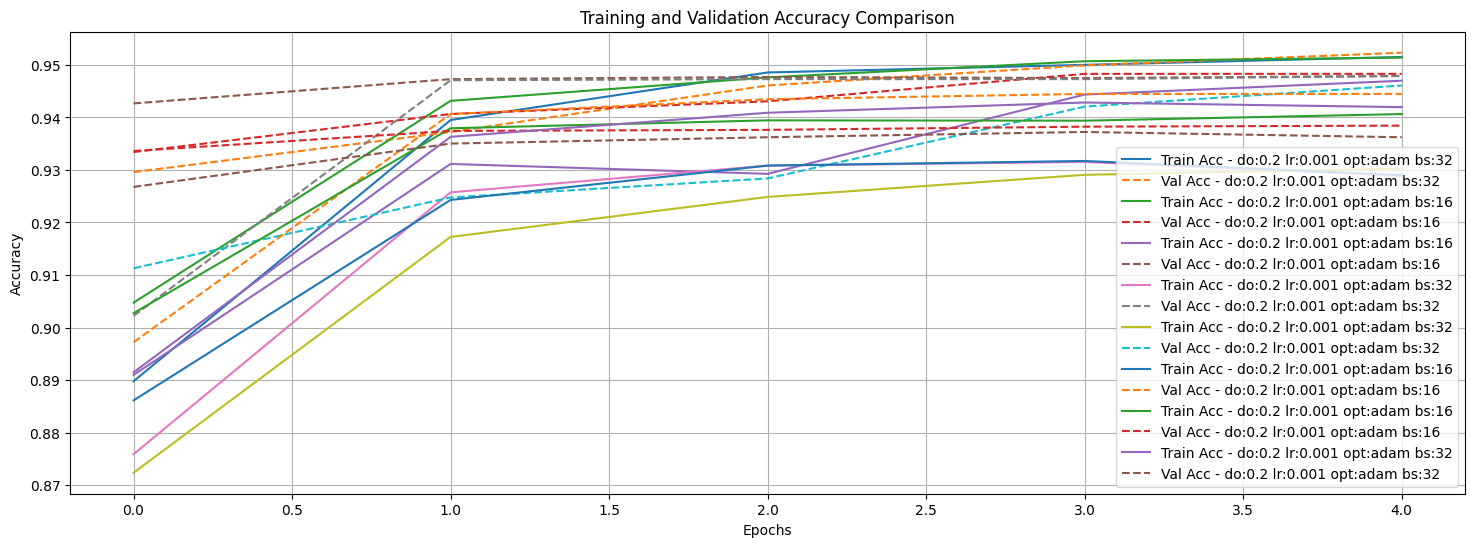

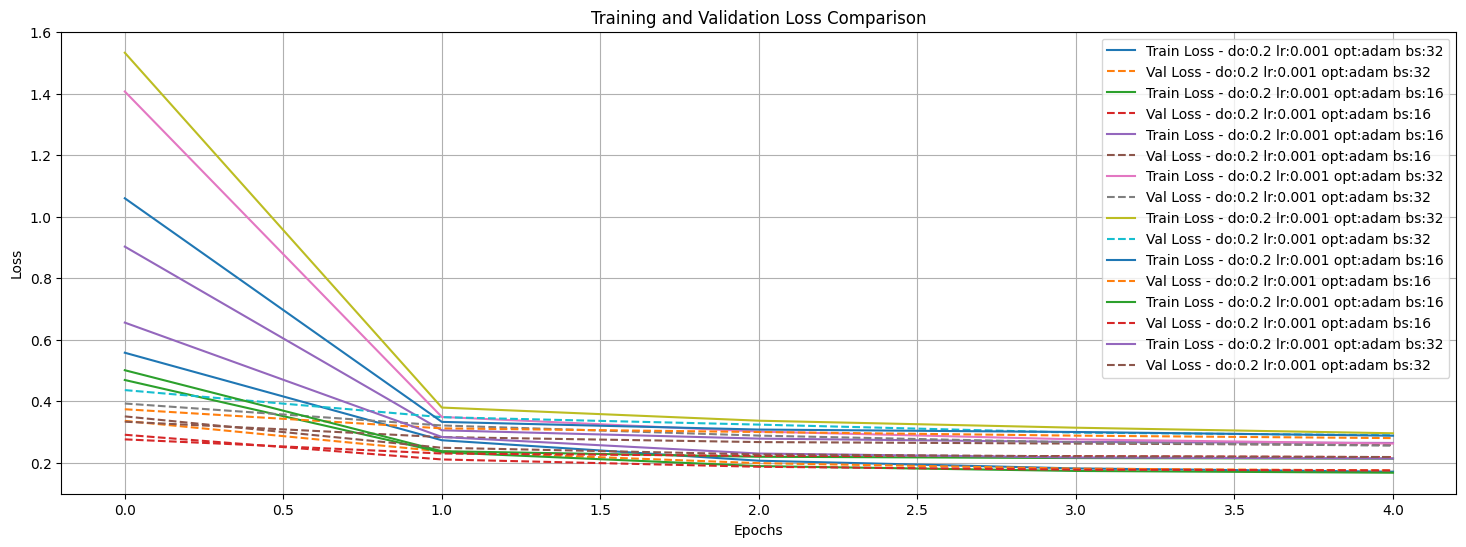

In [55]:
# Plot train/validation accuracy for best models
plt.figure(figsize=(18, 6))
for i, result in enumerate(top_acc_tuning_s3):
    config = result['config']
    config_str = f"do:{config['dropout']} lr:{config['lr']} opt:{config['optimizer']} bs:{config['batch_size']}"
    history_obj = result['history']
    
    plt.plot(history_obj.history['accuracy'], label=f"Train Acc - {config_str}")
    plt.plot(history_obj.history['val_accuracy'], linestyle='--', label=f"Val Acc - {config_str}")

plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot train/validation loss
plt.figure(figsize=(18, 6))
for i, result in enumerate(top_acc_tuning_s3):
    config = result['config']
    config_str = f"do:{config['dropout']} lr:{config['lr']} opt:{config['optimizer']} bs:{config['batch_size']}"
    history_obj = result['history']
    
    plt.plot(history_obj.history['loss'], label=f"Train Loss - {config_str}")
    plt.plot(history_obj.history['val_loss'], linestyle='--', label=f"Val Loss - {config_str}")

plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [56]:
# @tittle Model Evaluation

# --- Evaluation Function ---
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

def evaluate_trained_models(models, hist_metrics, X_test, y_test, 
                           class_names=None, verbose=True, return_curves=False):
    """
    Comprehensive model evaluation function optimized for imbalanced datasets
    
    Parameters:
    -----------
    models : list
        List of trained Keras models
    hist_metrics : list
        List of training history and config data
    X_test : array-like
        Test features
    y_test : array-like
        Test labels
    class_names : list, optional
        Names of classes for better reporting
    verbose : bool
        Print detailed results
    return_curves : bool
        Whether to return ROC and PR curve data
    
    Returns:
    --------
    results : list
        Comprehensive evaluation results for each model
    """
    
    # Set seeds for reproducible evaluation
    np.random.seed(42)
    
    results_tuning_s3 = []
    n_classes = len(np.unique(y_test))
    is_binary = n_classes == 2
    
    if verbose:
        print("="*80)
        print(f"EVALUATING {len(models)} MODELS ON TEST SET")
        print(f"Dataset: {len(y_test)} samples, {n_classes} classes")
        if is_binary:
            class_dist = np.bincount(y_test)
            print(f"Class distribution: {class_dist[0]}:{class_dist[1]} ({class_dist[1]/len(y_test)*100:.1f}% positive)")
        print("="*80)
    
    for i, (model, history_data) in enumerate(zip(models, hist_metrics)):
        config = history_data['config']
        model_name = f"do:{config['dropout']} lr:{config['lr']} opt:{config['optimizer']} bs:{config['batch_size']} L1:{config['l1_reg']} L2:{config['l2_reg']}"
        
        if verbose:
            print(f"\n{model_name}")
            print("-" * 50)
        
        try:
            # Get predictions
            y_pred_prob = model.predict(X_test, verbose=0)
            
            # Handle probability extraction
            if y_pred_prob.shape[1] > 1:  # Multi-class output
                y_pred_class = np.argmax(y_pred_prob, axis=1)
                if is_binary:
                    y_prob_positive = y_pred_prob[:, 1]  # Probability of positive class
                else:
                    y_prob_positive = y_pred_prob  # Keep all probabilities for multi-class
            else:  # Single output (shouldn't happen with softmax, but just in case)
                y_pred_prob = y_pred_prob.flatten()
                y_pred_class = (y_pred_prob > 0.5).astype(int)
                y_prob_positive = y_pred_prob
            
            # Basic metrics
            test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
            
            # Classification metrics
            if is_binary:
                # Binary classification metrics
                precision = precision_score(y_test, y_pred_class, zero_division=0)
                recall = recall_score(y_test, y_pred_class, zero_division=0)
                f1 = f1_score(y_test, y_pred_class, zero_division=0)
                
                # Class-specific metrics
                precision_per_class = precision_score(y_test, y_pred_class, average=None, zero_division=0)
                recall_per_class = recall_score(y_test, y_pred_class, average=None, zero_division=0)
                f1_per_class = f1_score(y_test, y_pred_class, average=None, zero_division=0)
                
                # ROC-AUC and PR-AUC (better for imbalanced data)
                roc_auc = roc_auc_score(y_test, y_prob_positive)
                pr_auc = average_precision_score(y_test, y_prob_positive)
                
                # Confusion matrix
                cm = confusion_matrix(y_test, y_pred_class)
                tn, fp, fn, tp = cm.ravel()
                
                # Additional metrics for imbalanced data
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Same as recall
                balanced_accuracy = (sensitivity + specificity) / 2
                
                # Matthews Correlation Coefficient (good for imbalanced data)
                mcc_denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
                mcc = ((tp * tn) - (fp * fn)) / mcc_denom if mcc_denom != 0 else 0
                
            else:
                # Multi-class metrics
                precision = precision_score(y_test, y_pred_class, average='weighted', zero_division=0)
                recall = recall_score(y_test, y_pred_class, average='weighted', zero_division=0)
                f1 = f1_score(y_test, y_pred_class, average='weighted', zero_division=0)
                
                precision_per_class = precision_score(y_test, y_pred_class, average=None, zero_division=0)
                recall_per_class = recall_score(y_test, y_pred_class, average=None, zero_division=0)
                f1_per_class = f1_score(y_test, y_pred_class, average=None, zero_division=0)
                
                roc_auc = roc_auc_score(y_test, y_prob_positive, multi_class='ovr', average='weighted')
                pr_auc = average_precision_score(y_test, y_prob_positive, average='weighted')
                
                cm = confusion_matrix(y_test, y_pred_class)
                balanced_accuracy = recall  # For multi-class, weighted recall approximates balanced accuracy
                mcc = np.nan  # MCC is complex for multi-class
                specificity = np.nan
                sensitivity = recall
            
            # Store comprehensive results
            result_tuning_s3 = {
                # Model info
                'model_index': i,
                'model_name': model_name,
                'config': config,
                
                
                # Basic metrics
                'accuracy': test_accuracy,
                'loss': test_loss,
                'balanced_accuracy': balanced_accuracy,
                
                # Main classification metrics
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'roc_auc': roc_auc,
                'pr_auc': pr_auc,  # Better than ROC-AUC for imbalanced data
                
                # Per-class metrics
                'precision_per_class': precision_per_class,
                'recall_per_class': recall_per_class,
                'f1_per_class': f1_per_class,
                
                # Imbalanced data specific metrics
                'specificity': specificity,
                'sensitivity': sensitivity,
                'mcc': mcc,
                
                # Predictions and probabilities
                'y_pred_prob': y_prob_positive,
                'y_pred_class': y_pred_class,
                'confusion_matrix': cm,
                
                # Training history metrics
                'val_accuracy': history_data.get('val_accuracy', np.nan),
                'val_loss': history_data.get('val_loss', np.nan),
                'train_accuracy': history_data.get('train_accuracy', np.nan),
                'train_loss': history_data.get('train_loss', np.nan),
            }
            
            
            # Add curve data if requested
            if return_curves and is_binary:
                fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_positive)
                precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_prob_positive)
                
                result_tuning_s3.update({
                    'roc_curve': {'fpr': fpr, 'tpr': tpr, 'thresholds': roc_thresholds},
                    'pr_curve': {'precision': precision_curve, 'recall': recall_curve, 'thresholds': pr_thresholds}
                })
            
            results_tuning_s3.append(result_tuning_s3)
            
            # Verbose output
            if verbose:
                print(f"Core Metrics:")
                print(f"Accuracy: {test_accuracy:.4f} | Balanced Acc: {balanced_accuracy:.4f}")
                print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
                print(f"AUC Scores:")
                print(f" ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
                
                if is_binary:
                    print(f"Imbalanced Metrics:")
                    print(f"Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}")
                    print(f"MCC: {mcc:.4f}")
                    print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
                
                print(f"Training Performance:")
                
                # Safely format training performance. Check if train_loss and val_loss are not None and numeric
                train_loss_val = history_data.get('train_loss', 'N/A')
                val_loss_val = history_data.get('val_loss', 'N/A')

                if isinstance(train_loss_val, (int, float)):
                    print(f"   Train Loss: {train_loss_val:.4f}")
                else:
                    print(f"   Train Loss: {train_loss_val}")

                if isinstance(val_loss_val, (int, float)):
                    print(f"   Val Loss: {val_loss_val:.4f}")
                else:
                    print(f"   Val Loss: {val_loss_val}")
                
        except Exception as e:
            print(f"Error evaluating {model_name}: {str(e)}")
            continue
    
    if verbose:
        print("\n" + "="*80)
        print("EVALUATION SUMMARY")
        print("="*80)
        
        # Create summary DataFrame
        summary_data_best_s3 = []
        for r in results_tuning_s3:
            summary_data_best_s3.append({
                'Model': r['model_name'],
                'ROC_AUC': r['roc_auc'],
                'PR_AUC': r['pr_auc'],
                'F1': r['f1'],
                'Bal_Acc': r['balanced_accuracy'],
                'MCC': r.get('mcc', np.nan)
            })
        
        summary_df_tuning_s3 = pd.DataFrame(summary_data_best_s3)
        
        positive_ratio = np.mean(y_test)
        if positive_ratio < 0.5:  # Positives are minority
            sort_col = 'PR_AUC'   # Focus on positive class performance
        elif positive_ratio >= 0.5:  # Positives are majority  
            sort_col = 'ROC_AUC' # Focus on negative class performance
        
        # Sort by ROC-AUC (or PR-AUC for heavily imbalanced data)
        summary_df_tuning_s3 = summary_df_tuning_s3.sort_values(sort_col, ascending=False)
        
        print(summary_df_tuning_s3.round(4).to_string(index=False))
        print(f"\nBest model by {sort_col}: {summary_df_tuning_s3.iloc[0]['Model']}")
    
    return results_tuning_s3


# Basic usage
test_results_s3_tuning = evaluate_trained_models(models_tuning_s3, histories_tuning_s3, X_test_scaled_s3, y_test_s3)



# Basic usage
test_results_s3_tuning = evaluate_trained_models(models_tuning_s3, histories_tuning_s3, X_test_scaled_s3, y_test_s3)

EVALUATING 8 MODELS ON TEST SET
Dataset: 3976 samples, 2 classes
Class distribution: 586:3390 (85.3% positive)

do:0.2 lr:0.001 opt:adam bs:16 L1:0.01 L2:0.01
--------------------------------------------------
Core Metrics:
Accuracy: 0.9484 | Balanced Acc: 0.9479
Precision: 0.9905 | Recall: 0.9487 | F1: 0.9691
AUC Scores:
 ROC-AUC: 0.9702 | PR-AUC: 0.9950
Imbalanced Metrics:
Sensitivity: 0.9487 | Specificity: 0.9471
MCC: 0.8206
Confusion Matrix: TN=555, FP=31, FN=174, TP=3216
Training Performance:
   Train Loss: N/A
   Val Loss: 0.2801

do:0.2 lr:0.001 opt:adam bs:16 L1:0.01 L2:0.001
--------------------------------------------------
Core Metrics:
Accuracy: 0.9499 | Balanced Acc: 0.9587
Precision: 0.9947 | Recall: 0.9463 | F1: 0.9699
AUC Scores:
 ROC-AUC: 0.9714 | PR-AUC: 0.9944
Imbalanced Metrics:
Sensitivity: 0.9463 | Specificity: 0.9710
MCC: 0.8308
Confusion Matrix: TN=569, FP=17, FN=182, TP=3208
Training Performance:
   Train Loss: N/A
   Val Loss: 0.2579

do:0.2 lr:0.001 opt:adam 

In [57]:
# Because there are too many models, sort and select top 10 AUC scores.
# Sorting models based on best metric.
positive_ratio = np.mean(y_test_s3)
if positive_ratio < 0.5:  # Positives are minority
    sort_col = 'pr_auc'   # Focus on positive class performance
    print(f"Positive class is minority ({positive_ratio:.2%}), sorting by PR-AUC")
else:  # Positives are majority
    sort_col = 'roc_auc'  # Focus on overall performance
    print(f"Positive class is majority ({positive_ratio:.2%}), sorting by ROC-AUC")
    
sorted_auc_tuning_s3 = sorted(test_results_s3_tuning, key=lambda x: x['roc_auc'], reverse=True)
top_auc_tuning_s3 = sorted_auc_tuning_s3[:15]

Positive class is majority (85.26%), sorting by ROC-AUC


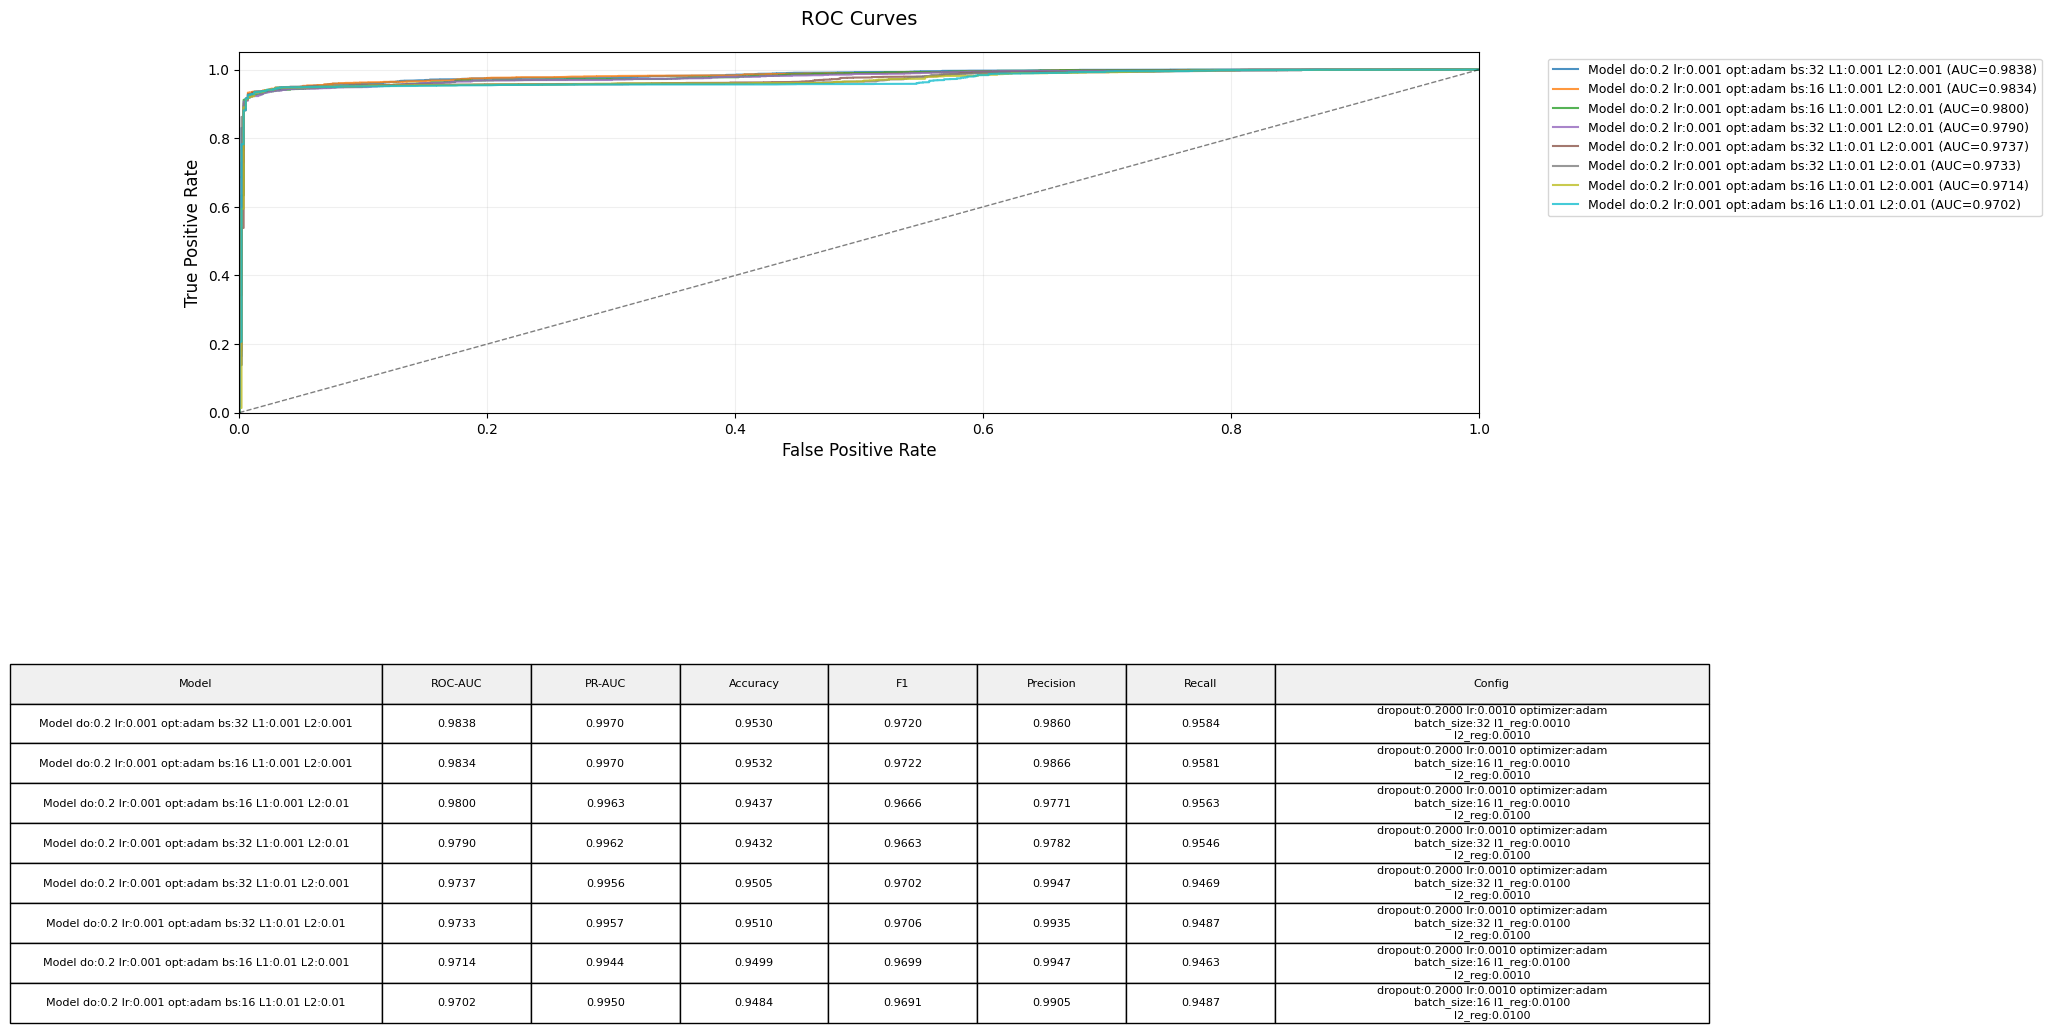

In [58]:
# @tittle ROC Curve for Learning Rate and Activation Function

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

def plot_roc_curves(test_results, X_test=None, y_test=None):
    """
    Enhanced ROC curve visualization with model names in legend and table,
    including both ROC-AUC and PR-AUC metrics.
    FIXED: Now uses the same probability extraction method as evaluation function
    """
    plt.figure(figsize=(16, 12))  # Increased figure size for two plots
    
    # Create color palette
    colors = plt.cm.tab10(np.linspace(0, 1, len(test_results)))
    
    # Create subplots with better layout
    ax1 = plt.subplot2grid((10, 2), (0, 0), colspan=2, rowspan=4)  # ROC plot area
    ax2 = plt.subplot2grid((10, 2), (7, 0), colspan=2, rowspan=3)  # Table area
    ax2.axis('off')
    
    # Prepare table data
    table_data = []
    col_labels = ['Model', 'ROC-AUC', 'PR-AUC', 'Accuracy', 'F1', 'Precision', 'Recall', 'Config']
    
    for i, res in enumerate(test_results):
        try:
            # Get model index and config
            model_idx = res.get('model_name', i)
            config = res['config']
            
            # Use stored probabilities from evaluation function
            # This ensures consistency between evaluation and plotting
            if 'y_pred_prob' in res and res['y_pred_prob'] is not None:
                y_score = res['y_pred_prob']  # This is already the positive class probability
            
            
            # Handle binary vs multi-class
            n_classes = len(np.unique(y_test))
            if n_classes == 2:  # Binary classification
                # FIXED: Use the SAME calculation method as evaluation function
                # Use roc_auc_score for consistency
                roc_auc = roc_auc_score(y_test, y_score)
                
                # Also calculate using roc_curve + auc (should be identical)
                fpr, tpr, _ = roc_curve(y_test, y_score)
                roc_auc_manual = auc(fpr, tpr)
                
                # Verify they match (within floating point precision)
                if abs(roc_auc - roc_auc_manual) > 1e-10:
                    print(f"Warning: ROC-AUC calculation mismatch for model {model_idx}")
                    print(f"  roc_auc_score: {roc_auc:.10f}")
                    print(f"  manual calc:   {roc_auc_manual:.10f}")
                
                # Use the same method as evaluation function
                pr_auc = average_precision_score(y_test, y_score)
                
                # Plot ROC curve
                ax1.plot(fpr, tpr, color=colors[i], lw=1.5, alpha=0.8,
                        label=f"Model {model_idx} (AUC={roc_auc:.4f})")
                
            else:  # Multi-class - kept same logic but using stored probabilities
                # Use stored full probability matrix
                y_prob = res.get('y_pred_prob_full', res.get('y_pred_prob'))
                if y_prob is None:
                    raise ValueError("No multi-class probability data found")
                
                # One-vs-Rest approach
                fpr, tpr, roc_auc_dict = {}, {}, {}
                
                for class_idx in range(n_classes):
                    fpr[class_idx], tpr[class_idx], _ = roc_curve((y_test == class_idx).astype(int), 
                                                               y_prob[:, class_idx])
                    roc_auc_dict[class_idx] = auc(fpr[class_idx], tpr[class_idx])
                
                # Micro-average metrics
                fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_prob.ravel())
                roc_auc = auc(fpr["micro"], tpr["micro"])
                
                precision, recall, _ = precision_recall_curve(y_test.ravel(), y_prob.ravel())
                pr_auc = auc(recall, precision)
                
                # Plot micro-average curves
                ax1.plot(fpr["micro"], tpr["micro"], color=colors[i], lw=1.5, alpha=0.8,
                        label=f"Model {model_idx} (Micro ROC AUC={roc_auc:.4f})")
            
            # Format config for display
            config_clean = {k: v for k, v in config.items() if k != 'model'}
            config_str = "\n".join([f"{k}:{v:.4f}" if isinstance(v, (float, np.floating)) 
                                  else f"{k}:{v}" 
                                  for k, v in config_clean.items()])
            
            # FIXED: Use the SAME values from evaluation results
            table_data.append([
                f"Model {model_idx}",
                f"{res.get('roc_auc', roc_auc):.4f}",  # Use stored value if available
                f"{res.get('pr_auc', pr_auc):.4f}",    # Use stored value if available
                f"{res.get('accuracy', 0):.4f}",
                f"{res.get('f1', 0):.4f}",
                f"{res.get('precision', 0):.4f}",
                f"{res.get('recall', 0):.4f}",
                config_str
            ])
            
        except Exception as e:
            print(f"Error processing model {i}: {str(e)}")
            continue
    
    # Format ROC plot
    ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title('ROC Curves', fontsize=14, pad=20)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax1.grid(alpha=0.2)
    
    # Create table with better formatting
    if table_data:
        # Wrap text in the config column (column 7) before creating the table
        wrapped_table_data = []
        for row in table_data:
            wrapped_row = []
            for i, cell_text in enumerate(row):
                if i == 7:  # Config column
                    # Wrap text to fit in ~30-35 characters per line
                    wrapped_text = '\n'.join(textwrap.wrap(str(cell_text), width=40))
                    wrapped_row.append(wrapped_text)
                else:
                    wrapped_row.append(cell_text)
            wrapped_table_data.append(wrapped_row)
        
        table = ax2.table(
            cellText=wrapped_table_data,
            colLabels=col_labels,
            loc='center',
            cellLoc='center',
            colColours=['#f0f0f0']*len(col_labels))
        
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.5)
        
        # Set specific column widths
        for i in range(len(col_labels)):
            for j in range(len(wrapped_table_data) + 1):
                cell = table[(j, i)]
                if i == 0:  # Config column
                    cell.set_width(0.30)
                    cell.set_height(0.15)  # Even taller for wrapped text
                elif i == 7:  # Config column
                    cell.set_width(0.35)
                    cell.set_height(0.15) 
                else:
                    cell.set_width(0.12)
                    cell.set_height(0.15)
    plt.show()

# Usage
plot_roc_curves(top_auc_tuning_s3, X_test=X_test_scaled_s3, y_test=y_test_s3)


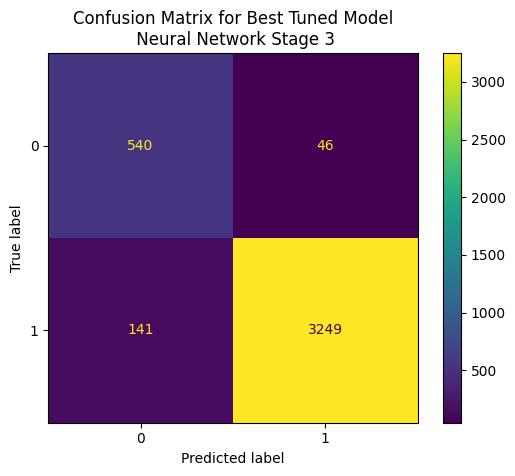

In [59]:
# Assuming test_results_s3_base is a list of dictionaries containing model results
for result in test_results_s3_tuning:
    # Check if this is the specific model we want
    if result.get('model_name') == 'do:0.2 lr:0.001 opt:adam bs:32 L1:0.001 L2:0.001' and 'confusion_matrix' in result:
        disp = ConfusionMatrixDisplay(confusion_matrix=result['confusion_matrix'])
        disp.plot()
        plt.title(f"Confusion Matrix for Best Tuned Model\n Neural Network Stage 3")
        plt.show()

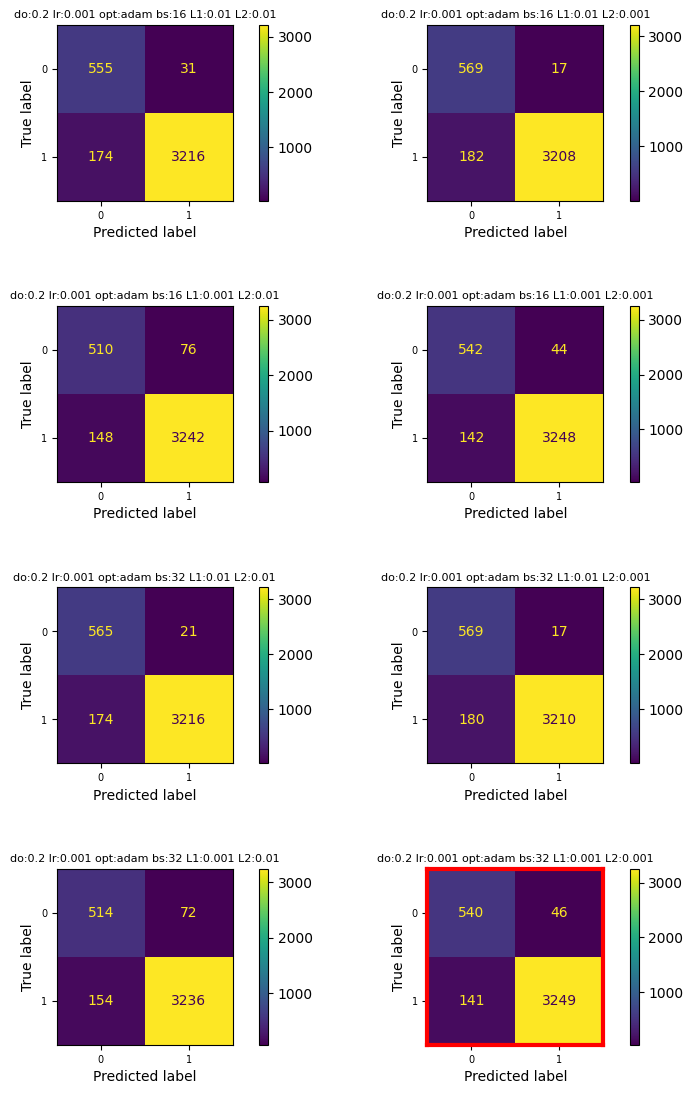

In [60]:
# Display top Tuned Model Tested

# Create the figure with adjusted spacing parameters
fig, axes = plt.subplots(4, 2, figsize=(10, 12))  # Reduced width from 12 to 10

# Main figure padding control
fig.tight_layout(pad=0.5)  # Reduced from 1.0

# Additional spacing controls:
plt.subplots_adjust(
    left=0.05,   # Reduced left margin
    right=0.95,  # Increased right margin 
    bottom=0.1,  # Bottom margin
    top=0.95,    # Increased top margin
    wspace=-0.3, # NEGATIVE spacing to overlap columns
    hspace=0.6   # Reduced vertical space between subplots
)

# Flatten the axes array for easier iteration
axes = axes.ravel()

# Counter for the current subplot
plot_idx = 0

# Find the best model by ROC-AUC
best_model = max(test_results_s3_tuning, key=lambda x: x.get('roc_auc', 0))
best_model_name = best_model.get('model_name')

for result in test_results_s3_tuning:
    # Stop if we've filled desired number of subplots
    if plot_idx >= 8:
        break
        
    # Check if this is the specific model we want
    if result.get('model_name') and 'confusion_matrix' in result:
        disp = ConfusionMatrixDisplay(confusion_matrix=result['confusion_matrix'])
        disp.plot(ax=axes[plot_idx])
        
        # Adjust title positioning and font size
        axes[plot_idx].set_title(
            f"{result['model_name']}",
            pad=5,   # Reduced padding from 10
            fontsize=8  # Smaller font size
        )
        
        # Add red border if this is the best model
        if result['model_name'] == best_model_name:
            for spine in axes[plot_idx].spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)
        
        # Adjust tick label sizes if needed
        axes[plot_idx].tick_params(axis='both', which='major', labelsize=7)
        
        plot_idx += 1

# Hide any remaining empty subplots
for i in range(plot_idx, 8):
    axes[i].axis('off')

plt.show()

### Model: do:0.2 lr:0.001 opt:adam bs:32 L1:0.001 L2:0.001: 1 hidden layers with 32 neurons. 

Activation: Relu, Softmax
Optimizer: Adam
Loss: Sparse Categorical Crossentropy
Dropout: 0.2
Learning Rate: 0.001
Batch Size: 32
L1 Regularization: 0.001
L2 Regularization: 0.001


- Learning curves assist with training decisions like early stopping, architecture selection, and stability assessment, but shouldn't be the only basis for final model choice. 
- Standard loss functions can be biased toward majority classes, masking poor minority class performance. That's why I used 'sparse_categorical_crossentropy,' which handles imbalanced datasets more effectively. 
- In imbalanced settings where positives are rare, traditional accuracy can be misleading—an accuracy of 80% might merely reflect always predicting the majority class. ROC-AUC remains a reliable metric for overall discriminative ability, while Precision-Recall AUC offers deeper insights into minority class performance. For model evaluation, I prioritized ROC-AUC, followed by Precision-Recall AUC, F1-score, Recall, and Precision, ensuring a balanced assessment of performance across metrics.


In [61]:
def compare_all_models(auc_tuning_s3, auc_base_s3=None, name_s3="Stage 3"):
    """
    Compare neural network models from Stage 3 analysis
    """
    data = []  # Initialize the data list
    
    # Get best models from each approach
    best_auc_tuned_s3 = max(auc_tuning_s3, key=lambda x: x.get('roc_auc', 0)) if auc_tuning_s3 else None
    best_auc_base_s3 = auc_base_s3[0] if auc_base_s3 else None
    
    # Add Stage 3 models
    stage3_models = [
        ('Best AUC (Base)', best_auc_base_s3),
        ('Best AUC (Tuned)', best_auc_tuned_s3)
    ]
    
    for model_type, model_data in stage3_models:
        if model_data:
            data.append({
                'Dataset': name_s3,
                'Model Type': model_type,
                'Model': model_data.get('model_name', 'Unknown'),
                'ROC-AUC': model_data.get('roc_auc', 0),
                'PR-AUC': model_data.get('pr_auc', 0),
                'Accuracy': model_data.get('accuracy', 0),
                'F1': model_data.get('f1', 0),
                'Precision': model_data.get('precision', 0),
                'Recall': model_data.get('recall', 0),
                'Config': str(model_data.get('config', {}))
            })
    
    # Create DataFrame
    comparison_df_s3 = pd.DataFrame(data)
    
    return comparison_df_s3

# Create the enhanced comparison DataFrame - FIXED: Removed unsupported parameters
all_models_df_s3 = compare_all_models(
    auc_tuning_s3=sorted_auc_tuning_s3,
    auc_base_s3=sorted_auc_base_s3,
    name_s3="Stage 3"
)

# Display with improved styling
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: gray' if v else '' for v in is_max]  

numeric_cols = ['ROC-AUC', 'PR-AUC', 'Accuracy', 'F1', 'Precision', 'Recall']

styled_df_s3 = (all_models_df_s3.style
    .apply(highlight_max, subset=numeric_cols)
    .format("{:.4f}", subset=numeric_cols)
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', "#4f6c9b"), ('color', 'white'), ('font-weight', 'bold')]
    }, {
        'selector': 'td',
        'props': [('border', '1px solid #ddd')]
    }])
    .set_properties(**{'text-align': 'center'})
)

display(styled_df_s3)

,Dataset,Model Type,Model,ROC-AUC,PR-AUC,Accuracy,F1,Precision,Recall,Config
0,Stage 3,Best AUC (Base),Model_5_2L_32U,0.9846,0.9973,0.0000,0.9724,0.9799,0.9649,"{'layers': 2, 'units': 32}"
1,Stage 3,Best AUC (Tuned),do:0.2 lr:0.001 opt:adam bs:32 L1:0.001 L2:0.001,0.9838,0.9970,0.9530,0.9720,0.9860,0.9584,"{'dropout': 0.2, 'lr': 0.001, 'optimizer': 'adam', 'batch_size': 32, 'l1_reg': 0.001, 'l2_reg': 0.001}"


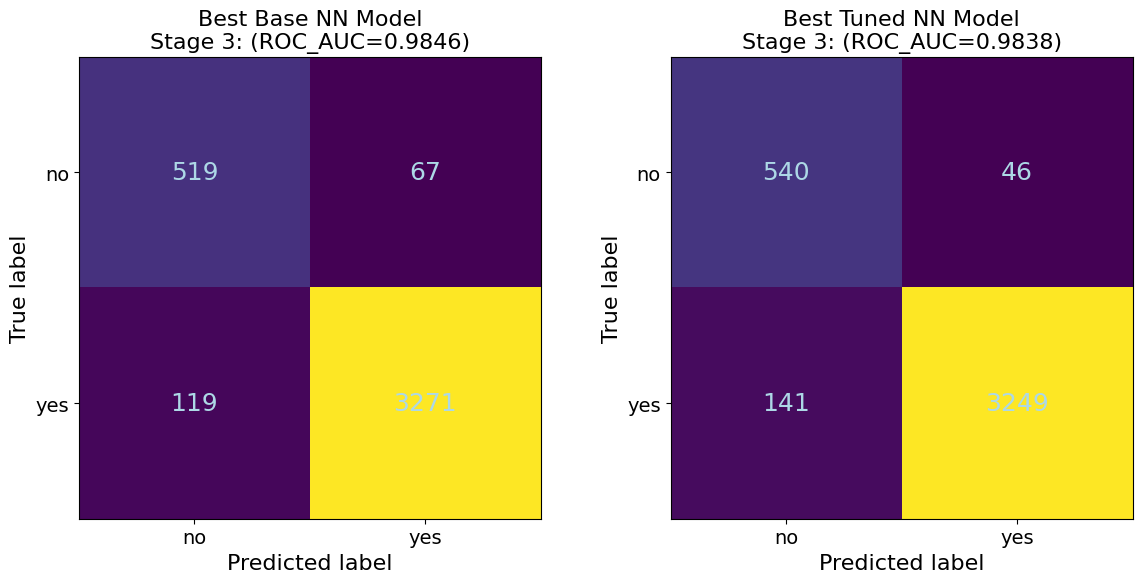

In [62]:
# Compute confusion matrices for best Neural Network models
# Find the best base model
best_base_nn_s3 = max(test_results_s3_base, key=lambda r: r['roc_auc'])
y_pred_base_nn_s3 = best_base_nn_s3['y_pred_class']
cm_base_nn_s3 = confusion_matrix(y_test_s3, y_pred_base_nn_s3)

# Find the best tuned model
best_tuning_nn_s3 = max(test_results_s3_tuning, key=lambda r: r['roc_auc'])
y_pred_tuned_nn_s3 = best_tuning_nn_s3['y_pred_class']
cm_tuned_nn_s3 = confusion_matrix(y_test_s3, y_pred_tuned_nn_s3)

# Base model
disp_base_nn_s3 = ConfusionMatrixDisplay(confusion_matrix=cm_base_nn_s3, display_labels=["no", "yes"])
disp_tuned_nn_s3 = ConfusionMatrixDisplay(confusion_matrix=cm_tuned_nn_s3, display_labels=["no", "yes"])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot confusion matrices
disp_base_nn_s3.plot(ax=axes[0], colorbar=False)
disp_tuned_nn_s3.plot(ax=axes[1], colorbar=False)

# Set titles with ROC_AUC info - FIXED: Use correct variable names
axes[0].set_title(f"Best Base NN Model\nStage 3: (ROC_AUC={best_base_nn_s3['roc_auc']:.4f})", fontsize=16)
axes[1].set_title(f"Best Tuned NN Model\nStage 3: (ROC_AUC={best_tuning_nn_s3['roc_auc']:.4f})", fontsize=16)

# Set axis labels with font size
axes[0].set_xlabel('Predicted label', fontsize=16)
axes[0].set_ylabel('True label', fontsize=16)
axes[1].set_xlabel('Predicted label', fontsize=16)
axes[1].set_ylabel('True label', fontsize=16)

# Remove grid lines
axes[0].grid(False)
axes[1].grid(False)

# Customize tick labels and cell fonts
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)
    for text in ax.texts:
        text.set_fontsize(18)
        text.set_color('lightblue')
        
plt.subplots_adjust(wspace=0.2, hspace=0.3)

plt.show()

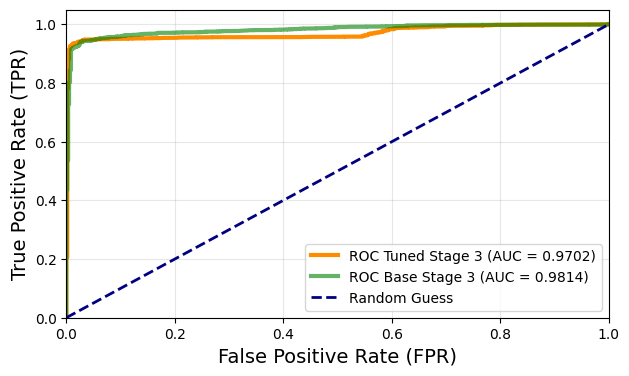

In [72]:
def plot_roc_curves_from_results(test_results_base, test_results_tuned, X_test=None, y_test=None,
                                label_base="Base Model", label_tuned="Tuned Model",
                                title=""):
    """
    Plots ROC curves for two models based on pre-calculated results stored in
    dictionaries, consistent with the format of 'test_results' in the first code.
    Handles single and multi-class cases. Assumes results already contain
    y_pred_prob.
    """

    # Extract necessary information from results
    model_base = test_results_base[0] if isinstance(test_results_base, list) else test_results_base
    model_tuned = test_results_tuned[0] if isinstance(test_results_tuned, list) else test_results_tuned

    y_score_base = model_base['y_pred_prob']
    y_score_tuned = model_tuned['y_pred_prob']

    n_classes = len(np.unique(y_test))

    # --- Plotting ---
    plt.figure(figsize=(7, 4))

    # --- Single Class ---
    if n_classes == 2:

        fpr_base, tpr_base, _ = roc_curve(y_test, y_score_base)
        roc_auc_base = auc(fpr_base, tpr_base)

        fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_score_tuned)
        roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

        # Plot the Tuned Model's ROC Curve
        plt.plot(fpr_tuned, tpr_tuned, color='darkorange', lw=3, alpha=1,
                 label=f'ROC {label_tuned} (AUC = {roc_auc_tuned:.4f})')

        # Plot the Base Model's ROC Curve
        plt.plot(fpr_base, tpr_base, color='green', lw=3, alpha=0.6,
                 label=f'ROC {label_base} (AUC = {roc_auc_base:.4f})')

    # --- Multi Class ---
    else:
        y_prob_base = model_base.get('y_pred_prob_full', model_base.get('y_pred_prob'))
        y_prob_tuned = model_tuned.get('y_pred_prob_full', model_tuned.get('y_pred_prob'))

        # Micro-average ROC
        fpr_base, tpr_base, _ = roc_curve(y_test.ravel(), y_prob_base.ravel())
        roc_auc_base = auc(fpr_base, tpr_base)

        fpr_tuned, tpr_tuned, _ = roc_curve(y_test.ravel(), y_prob_tuned.ravel())
        roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

        # Plot the Tuned Model's ROC Curve
        plt.plot(fpr_tuned, tpr_tuned, color='darkorange', lw=3, alpha=1,
                 label=f'ROC {label_tuned} (Micro AUC = {roc_auc_tuned:.4f})')

        # Plot the Base Model's ROC Curve
        plt.plot(fpr_base, tpr_base, color='green', lw=3, alpha=0.6,
                 label=f'ROC {label_base} (Micro AUC = {roc_auc_base:.4f})')

    # Plot the Random Guess line
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

    # --- Formatting the Plot ---
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=14)
    plt.ylabel('True Positive Rate (TPR)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

# Example Usage (assuming test_results_s3_base and test_results_s3_tuning exist):
plot_roc_curves_from_results(test_results_s3_base, test_results_s3_tuning,
                               X_test=X_test_scaled_s3, y_test=y_test_s3,
                               label_base="Base Stage 3", label_tuned="Tuned Stage 3")


## Final Model

In [64]:
# This is the model for 1 layer, 32 units and the following hyperparameters: droput:0.2 learning rate:0.001 optimizer:adam batch sizes:32 L1 regularization:0.001 L2 regularization:0.001

# Suppress TensorFlow warnings and logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress all TF logs (0=all, 1=info, 2=warning, 3=error)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN optimizations warnings
warnings.filterwarnings('ignore')

# Additional TensorFlow logging suppression
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

def set_global_determinism(seed):
    """Set seeds for reproducible results"""
    tf.random.set_seed(seed)
    np.random.seed(seed)

def create_model_tuning(input_dim, output_dim, layers=1, units=32, dropout=0.2, batch_size=16,
                       lr=0.001, optimizer='adam', seed=42,
                       l1_reg=0.0, l2_reg=0.0):
    """Create a deterministic neural network model with L1/L2 regularization"""
    # Reset seeds before each model creation
    tf.random.set_seed(seed)
    np.random.seed(seed)
    
    # Create regularization object
    kernel_regularizer = regularizers.L1L2(l1=l1_reg, l2=l2_reg) if (l1_reg > 0 or l2_reg > 0) else None
    
    model = Sequential(name=f"model_{layers}L_{units}U")
    model.add(InputLayer(shape=(input_dim,)))
    
    for _ in range(layers):
        model.add(Dense(units, activation='relu', 
                       kernel_regularizer=kernel_regularizer,
                       kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed),
                       bias_initializer=tf.keras.initializers.Zeros()))
        model.add(Dropout(dropout, seed=seed))
    
    model.add(Dense(output_dim, activation='softmax',
                   kernel_regularizer=kernel_regularizer,
                   kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed),
                   bias_initializer=tf.keras.initializers.Zeros()))
    
    # Choose optimizer
    if optimizer.lower() == 'adam':
        opt = Adam(learning_rate=lr)
    elif optimizer.lower() == 'rmsprop':
        opt = RMSprop(learning_rate=lr)
    else:
        opt = Adam(learning_rate=lr)  # default
    
    model.compile(optimizer=opt,
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return model

# Get dimensions (assuming X_train, y_train are defined)
input_dim = X_train_scaled_s3.shape[1]
output_dim = len(np.unique(y_train_s3))

# Hyperparameter grid with L1/L2 regularization options
hyperparameter_config = {
    'dropout': [0.2], 
    'lr': [0.001],
    'optimizer': ['adam'],
    'batch_size': [32],
    'l1_reg': [0.001],  # L1 regularization strengths
    'l2_reg': [0.001]   # L2 regularization strengths
}

models_best_s3 = []
histories_best_s3 = []

# Generate all combinations of hyperparameters
keys, values = zip(*hyperparameter_config.items())
configs = [dict(zip(keys, v)) for v in product(*values)]

# Initialize progress bar
progress_bar = tqdm(configs, desc="Hyperparameter Tuning", unit="model")

for i, config in enumerate(progress_bar):
    # Update progress bar description with current config
    short_desc = (f"do:{config['dropout']} lr:{config['lr']} opt:{config['optimizer']} "
                 f"bs:{config['batch_size']} L1:{config['l1_reg']} L2:{config['l2_reg']}")
    progress_bar.set_postfix(config=short_desc)
    
    # Set unique but deterministic seed for each model
    model_seed = 42 + i
    set_global_determinism(model_seed)
    
    # Clear session and memory
    tf.keras.backend.clear_session()
    gc.collect()
    
    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=3, 
                              restore_best_weights=True, verbose=0)
    
    # Create model with current config (excluding batch_size which is for training)
    model_config = {k: v for k, v in config.items() if k != 'batch_size'}
    model_best_s3 = create_model_tuning(input_dim, output_dim, seed=model_seed, **model_config)
    
    # Train model (NON-VERBOSE)
    history_best = model_best_s3.fit(
        X_train_scaled_s3, y_train_s3,
        validation_data=(X_val_scaled_s3, y_val_s3),
        batch_size=config['batch_size'],
        epochs=10,
        callbacks=[early_stop],
        shuffle=True,  # Deterministic due to seed
        verbose=0  # Silent training
    )
    
    # Evaluate model (NON-VERBOSE)
    val_loss_tuning_s3, val_acc_tuning_s3 = model_best_s3.evaluate(X_val_scaled_s3, y_val_s3, verbose=0)
    
    # Store results
    models_best_s3.append(model_best_s3)
    histories_best_s3.append({
        "config": config,
        "model": model_best_s3,
        "val_loss": val_loss_tuning_s3,
        "val_accuracy": val_acc_tuning_s3,
        "history": history_best,
        "seed": model_seed
    })
    
    # Clean up
    gc.collect()

# Close progress bar
progress_bar.close()

print(f"Hyperparameter tuning completed. Trained {len(models_best_s3)} models.")
print('Models: models_best_s3, Histories: histories_best_s3')


Hyperparameter Tuning: 100%|██████████| 1/1 [00:05<00:00,  5.64s/model, config=do:0.2 lr:0.001 opt:adam bs:32 L1:0.001 L2:0.001]

Hyperparameter tuning completed. Trained 1 models.
Models: models_best_s3, Histories: histories_best_s3


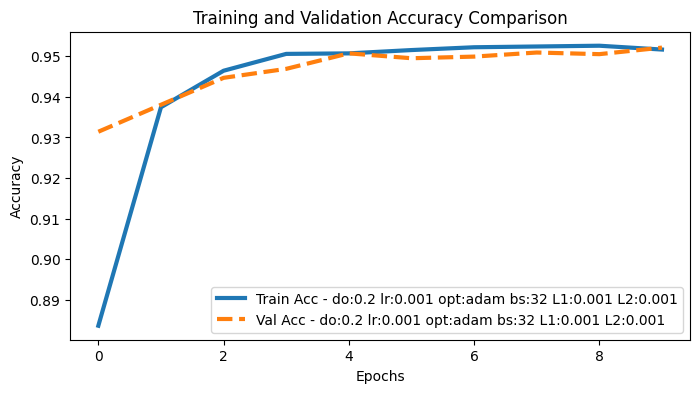

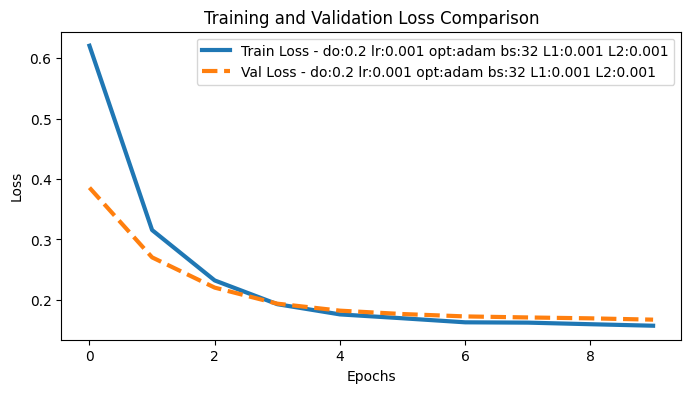

In [65]:
# Plot train/validation accuracy for best models
def learning_curve(histories):
    plt.figure(figsize=(8, 4))
    for i, result in enumerate(histories):
        config = result['config']
        config_str = f"do:{config['dropout']} lr:{config['lr']} opt:{config['optimizer']} bs:{config['batch_size']} L1:{config['l1_reg']} L2:{config['l2_reg']}"
        history_obj = result['history']
        
        plt.plot(history_obj.history['accuracy'], label=f"Train Acc - {config_str}", linewidth=3)
        plt.plot(history_obj.history['val_accuracy'], linestyle='--', linewidth=3, label=f"Val Acc - {config_str}")

    plt.title('Training and Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(False)
    plt.show()

    # Plot train/validation loss
    plt.figure(figsize=(8, 4))
    for i, result in enumerate(histories):
        config = result['config']
        config_str = f"do:{config['dropout']} lr:{config['lr']} opt:{config['optimizer']} bs:{config['batch_size']} L1:{config['l1_reg']} L2:{config['l2_reg']}"
        history_obj = result['history']
        
        plt.plot(history_obj.history['loss'], label=f"Train Loss - {config_str}", linewidth=3)
        plt.plot(history_obj.history['val_loss'], linestyle='--', linewidth=3, label=f"Val Loss - {config_str}")

    plt.title('Training and Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(False)
    plt.show()

learning_curve(histories_best_s3)

In [66]:
# @tittle Model Evaluation

# --- Evaluation Function ---
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

def evaluate_trained_models(models, hist_metrics, X_test, y_test, 
                           class_names=None, verbose=True, return_curves=False):
    """
    Comprehensive model evaluation function optimized for imbalanced datasets
    
    Parameters:
    -----------
    models : list
        List of trained Keras models
    hist_metrics : list
        List of training history and config data
    X_test : array-like
        Test features
    y_test : array-like
        Test labels
    class_names : list, optional
        Names of classes for better reporting
    verbose : bool
        Print detailed results
    return_curves : bool
        Whether to return ROC and PR curve data
    
    Returns:
    --------
    results : list
        Comprehensive evaluation results for each model
    """
    
    # Set seeds for reproducible evaluation
    np.random.seed(42)
    
    results_best_s3 = []
    n_classes = len(np.unique(y_test))
    is_binary = n_classes == 2
    
    if verbose:
        print("="*80)
        print(f"EVALUATING {len(models)} MODELS ON TEST SET")
        print(f"Dataset: {len(y_test)} samples, {n_classes} classes")
        if is_binary:
            class_dist = np.bincount(y_test)
            print(f"Class distribution: {class_dist[0]}:{class_dist[1]} ({class_dist[1]/len(y_test)*100:.1f}% positive)")
        print("="*80)
    
    for i, (model, history_data) in enumerate(zip(models, hist_metrics)):
        config = history_data['config']
        model_name = f"do:{config['dropout']} lr:{config['lr']} opt:{config['optimizer']} bs:{config['batch_size']} L1:{config['l1_reg']} L2:{config['l2_reg']}"
        
        if verbose:
            print(f"\n{model_name}")
            print("-" * 50)
        
        try:
            # Get predictions
            y_pred_prob = model.predict(X_test, verbose=0)
            
            # Handle probability extraction
            if y_pred_prob.shape[1] > 1:  # Multi-class output
                y_pred_class = np.argmax(y_pred_prob, axis=1)
                if is_binary:
                    y_prob_positive = y_pred_prob[:, 1]  # Probability of positive class
                else:
                    y_prob_positive = y_pred_prob  # Keep all probabilities for multi-class
            else:  # Single output (shouldn't happen with softmax, but just in case)
                y_pred_prob = y_pred_prob.flatten()
                y_pred_class = (y_pred_prob > 0.5).astype(int)
                y_prob_positive = y_pred_prob
            
            # Basic metrics
            test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
            
            # Classification metrics
            if is_binary:
                # Binary classification metrics
                precision = precision_score(y_test, y_pred_class, zero_division=0)
                recall = recall_score(y_test, y_pred_class, zero_division=0)
                f1 = f1_score(y_test, y_pred_class, zero_division=0)
                
                # Class-specific metrics
                precision_per_class = precision_score(y_test, y_pred_class, average=None, zero_division=0)
                recall_per_class = recall_score(y_test, y_pred_class, average=None, zero_division=0)
                f1_per_class = f1_score(y_test, y_pred_class, average=None, zero_division=0)
                
                # ROC-AUC and PR-AUC (better for imbalanced data)
                roc_auc = roc_auc_score(y_test, y_prob_positive)
                pr_auc = average_precision_score(y_test, y_prob_positive)
                
                # Confusion matrix
                cm = confusion_matrix(y_test, y_pred_class)
                tn, fp, fn, tp = cm.ravel()
                
                # Additional metrics for imbalanced data
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Same as recall
                balanced_accuracy = (sensitivity + specificity) / 2
                
                # Matthews Correlation Coefficient (good for imbalanced data)
                mcc_denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
                mcc = ((tp * tn) - (fp * fn)) / mcc_denom if mcc_denom != 0 else 0
                
            else:
                # Multi-class metrics
                precision = precision_score(y_test, y_pred_class, average='weighted', zero_division=0)
                recall = recall_score(y_test, y_pred_class, average='weighted', zero_division=0)
                f1 = f1_score(y_test, y_pred_class, average='weighted', zero_division=0)
                
                precision_per_class = precision_score(y_test, y_pred_class, average=None, zero_division=0)
                recall_per_class = recall_score(y_test, y_pred_class, average=None, zero_division=0)
                f1_per_class = f1_score(y_test, y_pred_class, average=None, zero_division=0)
                
                roc_auc = roc_auc_score(y_test, y_prob_positive, multi_class='ovr', average='weighted')
                pr_auc = average_precision_score(y_test, y_prob_positive, average='weighted')
                
                cm = confusion_matrix(y_test, y_pred_class)
                balanced_accuracy = recall  # For multi-class, weighted recall approximates balanced accuracy
                mcc = np.nan  # MCC is complex for multi-class
                specificity = np.nan
                sensitivity = recall
            
            # Store comprehensive results
            result_best_s3 = {
                # Model info
                'model_index': i,
                'model_name': model_name,
                'config': config,
                
                
                # Basic metrics
                'accuracy': test_accuracy,
                'loss': test_loss,
                'balanced_accuracy': balanced_accuracy,
                
                # Main classification metrics
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'roc_auc': roc_auc,
                'pr_auc': pr_auc,  # Better than ROC-AUC for imbalanced data
                
                # Per-class metrics
                'precision_per_class': precision_per_class,
                'recall_per_class': recall_per_class,
                'f1_per_class': f1_per_class,
                
                # Imbalanced data specific metrics
                'specificity': specificity,
                'sensitivity': sensitivity,
                'mcc': mcc,
                
                # Predictions and probabilities
                'y_pred_prob': y_prob_positive,
                'y_pred_class': y_pred_class,
                'confusion_matrix': cm,
                
                # Training history metrics
                'val_accuracy': history_data.get('val_accuracy', np.nan),
                'val_loss': history_data.get('val_loss', np.nan),
                'train_accuracy': history_data.get('train_accuracy', np.nan),
                'train_loss': history_data.get('train_loss', np.nan),
            }
            
            
            # Add curve data if requested
            if return_curves and is_binary:
                fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_positive)
                precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_prob_positive)
                
                result_best_s3.update({
                    'roc_curve': {'fpr': fpr, 'tpr': tpr, 'thresholds': roc_thresholds},
                    'pr_curve': {'precision': precision_curve, 'recall': recall_curve, 'thresholds': pr_thresholds}
                })
            
            results_best_s3.append(result_best_s3)
            
            # Verbose output
            if verbose:
                print(f"Core Metrics:")
                print(f"Accuracy: {test_accuracy:.4f} | Balanced Acc: {balanced_accuracy:.4f}")
                print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
                print(f"AUC Scores:")
                print(f" ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
                
                if is_binary:
                    print(f"Imbalanced Metrics:")
                    print(f"Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}")
                    print(f"MCC: {mcc:.4f}")
                    print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
                
                print(f"Training Performance:")
                
                # Safely format training performance. Check if train_loss and val_loss are not None and numeric
                train_loss_val = history_data.get('train_loss', None)
                val_loss_val = history_data.get('val_loss', None)

                if isinstance(train_loss_val, (int, float)):
                    print(f"   Train Loss: {train_loss_val:.4f}")
                else:
                    print(f"   Train Loss: {train_loss_val}")

                if isinstance(val_loss_val, (int, float)):
                    print(f"   Val Loss: {val_loss_val:.4f}")
                else:
                    print(f"   Val Loss: {val_loss_val}")
                
        except Exception as e:
            print(f"Error evaluating {model_name}: {str(e)}")
            continue
    
    if verbose:
        print("\n" + "="*80)
        print("EVALUATION SUMMARY")
        print("="*80)
        
        # Create summary DataFrame
        summary_data_best_s3 = []
        for r in results_best_s3:
            summary_data_best_s3.append({
                'Model': r['model_name'],
                'ROC_AUC': r['roc_auc'],
                'PR_AUC': r['pr_auc'],
                'F1': r['f1'],
                'Bal_Acc': r['balanced_accuracy'],
                'MCC': r.get('mcc', np.nan)
            })
        
        summary_df = pd.DataFrame(summary_data_best_s3)
        
        positive_ratio = np.mean(y_test)
        if positive_ratio < 0.5:  # Positives are minority
            sort_col = 'PR_AUC'   # Focus on positive class performance
        elif positive_ratio >= 0.5:  # Positives are majority  
            sort_col = 'ROC_AUC' # Focus on negative class performance
        
        # Sort by ROC-AUC (or PR-AUC for heavily imbalanced data)
        summary_df = summary_df.sort_values(sort_col, ascending=False)
        
        print(summary_df.round(4).to_string(index=False))
        print(f"\nBest model by {sort_col}: {summary_df.iloc[0]['Model']}")
    
    return results_best_s3


# Basic usage
test_results_s3_best = evaluate_trained_models(models_best_s3, histories_best_s3, X_test_scaled_s3, y_test_s3)


EVALUATING 1 MODELS ON TEST SET
Dataset: 3976 samples, 2 classes
Class distribution: 586:3390 (85.3% positive)

do:0.2 lr:0.001 opt:adam bs:32 L1:0.001 L2:0.001
--------------------------------------------------
Core Metrics:
Accuracy: 0.9535 | Balanced Acc: 0.9374
Precision: 0.9849 | Recall: 0.9602 | F1: 0.9724
AUC Scores:
 ROC-AUC: 0.9842 | PR-AUC: 0.9970
Imbalanced Metrics:
Sensitivity: 0.9602 | Specificity: 0.9147
MCC: 0.8280
Confusion Matrix: TN=536, FP=50, FN=135, TP=3255
Training Performance:
   Train Loss: None
   Val Loss: 0.1673

EVALUATION SUMMARY
                                           Model  ROC_AUC  PR_AUC     F1  Bal_Acc   MCC
do:0.2 lr:0.001 opt:adam bs:32 L1:0.001 L2:0.001   0.9842   0.997 0.9724   0.9374 0.828

Best model by ROC_AUC: do:0.2 lr:0.001 opt:adam bs:32 L1:0.001 L2:0.001


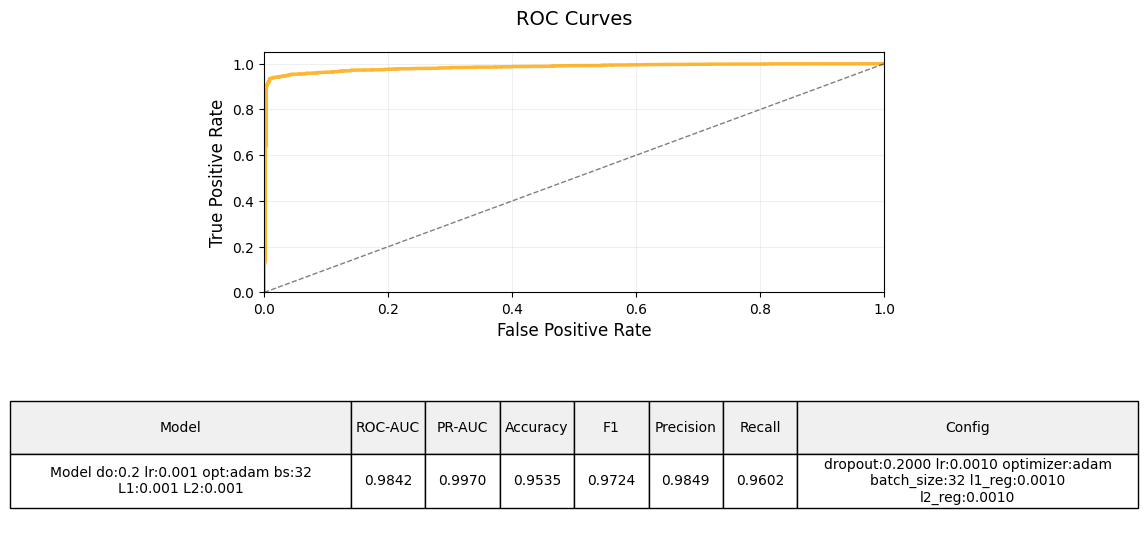

In [67]:
# @tittle ROC Curve for Learning Rate and Activation Function

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

def plot_roc_curves(test_results, X_test=None, y_test=None):
    """
    Enhanced ROC curve visualization with model names in legend and table,
    including both ROC-AUC and PR-AUC metrics.
    FIXED: Now uses the same probability extraction method as evaluation function
    """
    plt.figure(figsize=(8, 8))  # Increased figure size for two plots
    
    # Create color palette
    colors = plt.cm.tab10(np.linspace(0, 1, len(test_results)))
    
    # Create subplots with better layout
    ax1 = plt.subplot2grid((10, 2), (0, 0), colspan=2, rowspan=4)  # ROC plot area
    ax2 = plt.subplot2grid((10, 2), (5, 0), colspan=2, rowspan=3)  # Table area
    ax2.axis('off')
    
    # Prepare table data
    table_data = []
    col_labels = ['Model', 'ROC-AUC', 'PR-AUC', 'Accuracy', 'F1', 'Precision', 'Recall', 'Config']
    
    for i, res in enumerate(test_results):
        try:
            # Get model index and config
            model_idx = res.get('model_name', i)
            config = res['config']
            
            # Use stored probabilities from evaluation function
            # This ensures consistency between evaluation and plotting
            if 'y_pred_prob' in res and res['y_pred_prob'] is not None:
                y_score = res['y_pred_prob']  # This is already the positive class probability
            
            
            # Handle binary vs multi-class
            n_classes = len(np.unique(y_test))
            if n_classes == 2:  # Binary classification
                # FIXED: Use the SAME calculation method as evaluation function
                # Use roc_auc_score for consistency
                roc_auc = roc_auc_score(y_test, y_score)
                
                # Also calculate using roc_curve + auc (should be identical)
                fpr, tpr, _ = roc_curve(y_test, y_score)
                roc_auc_manual = auc(fpr, tpr)
                
                # Verify they match (within floating point precision)
                if abs(roc_auc - roc_auc_manual) > 1e-10:
                    print(f"Warning: ROC-AUC calculation mismatch for model {model_idx}")
                    print(f"  roc_auc_score: {roc_auc:.10f}")
                    print(f"  manual calc:   {roc_auc_manual:.10f}")
                
                # Use the same method as evaluation function
                pr_auc = average_precision_score(y_test, y_score)
                
                # Plot ROC curve
                ax1.plot(fpr, tpr, color='orange', lw=2.5, alpha=0.8,
                        label=f"Model {model_idx} (AUC={roc_auc:.4f})")
                
            else:  # Multi-class - kept same logic but using stored probabilities
                # Use stored full probability matrix
                y_prob = res.get('y_pred_prob_full', res.get('y_pred_prob'))
                if y_prob is None:
                    raise ValueError("No multi-class probability data found")
                
                # One-vs-Rest approach
                fpr, tpr, roc_auc_dict = {}, {}, {}
                
                for class_idx in range(n_classes):
                    fpr[class_idx], tpr[class_idx], _ = roc_curve((y_test == class_idx).astype(int), 
                                                               y_prob[:, class_idx])
                    roc_auc_dict[class_idx] = auc(fpr[class_idx], tpr[class_idx])
                
                # Micro-average metrics
                fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_prob.ravel())
                roc_auc = auc(fpr["micro"], tpr["micro"])
                
                precision, recall, _ = precision_recall_curve(y_test.ravel(), y_prob.ravel())
                pr_auc = auc(recall, precision)
                
                # Plot micro-average curves
                ax1.plot(fpr["micro"], tpr["micro"], color=colors[i], lw=1.5, alpha=0.8,
                        label=f"Model {model_idx} (Micro ROC AUC={roc_auc:.4f})")
            
            # Format config for display
            config_clean = {k: v for k, v in config.items() if k != 'model'}
            config_str = "\n".join([f"{k}:{v:.4f}" if isinstance(v, (float, np.floating)) 
                                  else f"{k}:{v}" 
                                  for k, v in config_clean.items()])
            
            # FIXED: Use the SAME values from evaluation results
            table_data.append([
                f"Model {model_idx}",
                f"{res.get('roc_auc', roc_auc):.4f}",  # Use stored value if available
                f"{res.get('pr_auc', pr_auc):.4f}",    # Use stored value if available
                f"{res.get('accuracy', 0):.4f}",
                f"{res.get('f1', 0):.4f}",
                f"{res.get('precision', 0):.4f}",
                f"{res.get('recall', 0):.4f}",
                config_str
            ])
            
        except Exception as e:
            print(f"Error processing model {i}: {str(e)}")
            continue
    
    # Format ROC plot
    ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title('ROC Curves', fontsize=14, pad=20)
    #ax1.legend(bbox_to_anchor=(1.05, 1), loc='center', fontsize=9)
    ax1.grid(alpha=0.2)
    
    # Create table with better formatting
    if table_data:
        # Wrap text in the config column (column 7) before creating the table
        wrapped_table_data = []
        for row in table_data:
            wrapped_row = []
            for i, cell_text in enumerate(row):
                if i in (0,7):  # Config column
                    # Wrap text to fit in ~30-35 characters per line
                    wrapped_text = '\n'.join(textwrap.wrap(str(cell_text), width=40))
                    wrapped_row.append(wrapped_text)
                else:
                    wrapped_row.append(cell_text)
            wrapped_table_data.append(wrapped_row)
        
        table = ax2.table(
            cellText=wrapped_table_data,
            colLabels=col_labels,
            loc='center',
            cellLoc='center',
            colColours=['#f0f0f0']*len(col_labels))
        
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2.5)
        
        # Set specific column widths
        for i in range(len(col_labels)):
            for j in range(len(wrapped_table_data) + 1):
                cell = table[(j, i)]
                if i == 0:  # Config column
                    cell.set_width(0.55)
                    cell.set_height(0.3)  # Even taller for wrapped text
                elif i == 7:  # Config column
                    cell.set_width(0.55)
                    cell.set_height(0.3) 
                else:
                    cell.set_width(0.12)
                    cell.set_height(0.3)
    plt.show()

# Usage
plot_roc_curves(test_results_s3_best, X_test=X_test_scaled_s3, y_test=y_test_s3)


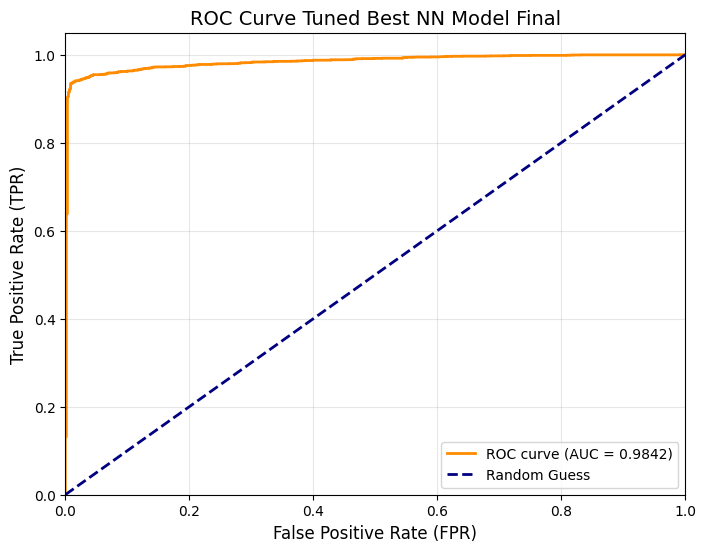

In [68]:
# Calculate ROC curve
# Plot based on stored probabilities from evaluate function
y_pred_proba_best = test_results_s3_best[0]['y_pred_prob']
fpr, tpr, thresholds = roc_curve(y_test_s3, y_pred_proba_best)
roc_auc_best = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC curve (AUC = {roc_auc_best:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve Tuned Best NN Model Final', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

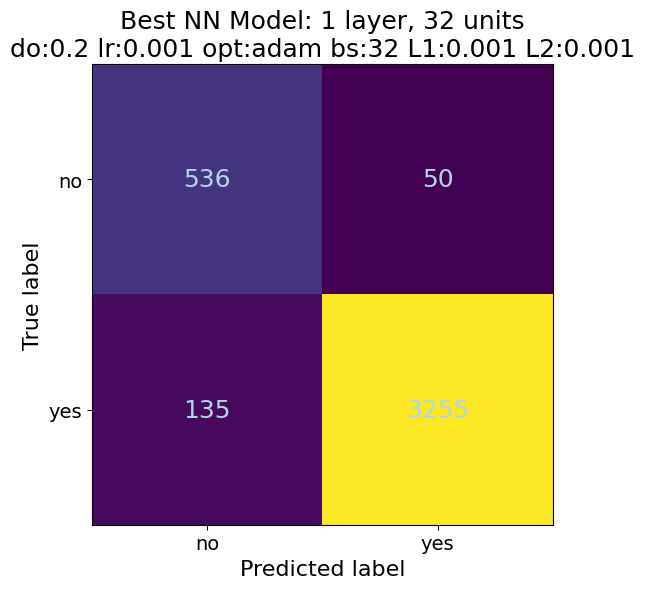

In [69]:
# Assuming test_results_s3_base is a list of dictionaries containing model results
# Assuming test_results_s3_best is a list of dictionaries containing model results
model_name_to_plot = 'do:0.2 lr:0.001 opt:adam bs:32 L1:0.001 L2:0.001'  # Define model name

# Create a figure and a single set of axes BEFORE the loop
fig, ax = plt.subplots(figsize=(8, 6))  # Create a figure and an axes

# Set the seed
np.random.seed(42)

# Create the confusion matrix plot if it exist.
for result in test_results_s3_best:
    # Check if this is the specific model we want and if it has confusion_matrix
    if result.get('model_name') == model_name_to_plot and 'confusion_matrix' in result:
        # Plot the confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=result['confusion_matrix'], display_labels=["no", "yes"])
        disp.plot(ax=ax, colorbar=False)

        # Set axis labels with font size
        ax.set_xlabel('Predicted label', fontsize=16)
        ax.set_ylabel('True label', fontsize=16)

        # Customize tick labels and cell fonts
        ax.tick_params(axis='both', which='major', labelsize=14)
        for text in ax.texts:
            text.set_fontsize(18)
            text.set_color('lightblue')

        plt.title(f"Best NN Model: 1 layer, 32 units\n{model_name_to_plot}", fontsize=18)

        # Adjust layout to prevent labels from overlapping
        plt.tight_layout()

        # Show the plot
        plt.show()